# Forecast model delay tests

This notebook checks AWS file metadata and calculates delay characteristics for various forecast models, cycle times, and lead times. 

Make sure to check out https://dynamical.org/research/when-the-forecast-is-ready/ and https://dynamical.org/status/pipeline/. 

Browsable IFS bucket: https://console.cloud.google.com/storage/browser/ecmwf-open-data/20260601/00z

In [1]:
!uv pip install boto3 matplotlib pandas statsmodels

Audited 4 packages in 1.79s


In [2]:
import boto3
import boto3
from botocore.handlers import disable_signing
import pandas as pd
# import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# from datetime import datetime, timedelta
# from dateutil.tz import tzutc

In [3]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

Note: this notebook/gist previously used `sklearn.linear_model.QuantileRegressor`, but it could take 4+ minutes to fit 2 quantiles. Switching to `statsmodels` `quantreg` cut that down to about 1 second.

## GFS

### List of dates

Get a random list of `n` dates between `start` and `end`, with a date format
that matches the AWS folder stucture for the NWP we are looking at:

In [4]:
n = 200  # number of random dates
start = '2025-01-15'  # start of random dates
end = '2026-07-15'  # end of random dates
date_format = '%Y%m%d' #  e.g., 20250101

possible_dates = pd.date_range(start, end, freq='1D')
np.random.seed(42)
idx_random = np.random.permutation(len(possible_dates))[:n]
rand_dates = possible_dates[idx_random].strftime(date_format)
print(rand_dates)

Index(['20250710', '20250402', '20260111', '20250415', '20260118', '20250813',
       '20250711', '20250922', '20260617', '20250802',
       ...
       '20250927', '20250120', '20250511', '20250301', '20250821', '20260621',
       '20250131', '20250304', '20260516', '20260226'],
      dtype='str', length=200)


### AWS info

Test/demo of retrieving filenames and last modified date for all files in an AWS "subfolder" in the GFS bucket. The bucket is named `noaa-gfs-bdp-pds`, and the folders we want look like `gfs.20260413`, and subfolders are initilization times (`00`, `06`, `12`, or `18`). See https://registry.opendata.aws/noaa-gfs-bdp-pds/.

In [5]:
# Based on:
#
# Source - https://stackoverflow.com/a/47100454
# Posted by alitheg
# Retrieved 2026-04-16, License - CC BY-SA 3.0
#
# Source - https://stackoverflow.com/a/71344187
# Posted by jarmod, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-16, License - CC BY-SA 4.0
#
# Source - https://stackoverflow.com/a/62337309
# Posted by bonney
# Retrieved 2026-04-16, License - CC BY-SA 4.0

cycle = '00'
date = '20250914'

client = boto3.client('s3')
client.meta.events.register('choose-signer.s3.*', disable_signing)

response = client.list_objects_v2(
    Bucket='noaa-gfs-bdp-pds',
    Prefix=(f'gfs.{date}/{cycle}/atmos/gfs'))

max = 20  # max number of files to print 
i = 1
for content in response.get('Contents', []):
    print(content['Key'], content['LastModified'])
    i += 1
    if i > max:
        break

gfs.20250914/00/atmos/gfs.t00z.atmanl.nc 2025-09-14 04:04:48+00:00
gfs.20250914/00/atmos/gfs.t00z.atmf000.nc 2025-09-14 03:42:42+00:00
gfs.20250914/00/atmos/gfs.t00z.atmf001.nc 2025-09-14 03:39:50+00:00
gfs.20250914/00/atmos/gfs.t00z.atmf002.nc 2025-09-14 03:45:08+00:00
gfs.20250914/00/atmos/gfs.t00z.atmf003.nc 2025-09-14 03:45:29+00:00
gfs.20250914/00/atmos/gfs.t00z.atmf004.nc 2025-09-14 03:45:51+00:00
gfs.20250914/00/atmos/gfs.t00z.atmf005.nc 2025-09-14 03:49:27+00:00
gfs.20250914/00/atmos/gfs.t00z.atmf006.nc 2025-09-14 03:48:36+00:00
gfs.20250914/00/atmos/gfs.t00z.atmf007.nc 2025-09-14 03:46:47+00:00
gfs.20250914/00/atmos/gfs.t00z.atmf008.nc 2025-09-14 03:45:40+00:00
gfs.20250914/00/atmos/gfs.t00z.atmf009.nc 2025-09-14 03:54:09+00:00
gfs.20250914/00/atmos/gfs.t00z.atmf010.nc 2025-09-14 03:50:34+00:00
gfs.20250914/00/atmos/gfs.t00z.atmf011.nc 2025-09-14 03:52:09+00:00
gfs.20250914/00/atmos/gfs.t00z.atmf012.nc 2025-09-14 03:57:09+00:00
gfs.20250914/00/atmos/gfs.t00z.bufrsnd.tar.gz 202

The output of `response.get('Contents', [])` is a list of dictionaries. We can turn that into a DataFrame. 

In [6]:
df = pd.DataFrame(response.get('Contents', []))
df.head()

,Key,LastModified,ETag,ChecksumAlgorithm,ChecksumType,Size,StorageClass
0,gfs.20250914/00/atmos/gfs.t00z.atmanl.nc,2025-09-14 04:04:48+00:00,"""5eb789d2af00afed2886ef13462db68f-266""",[CRC64NVME],FULL_OBJECT,13920921242,STANDARD
1,gfs.20250914/00/atmos/gfs.t00z.atmf000.nc,2025-09-14 03:42:42+00:00,"""a6d5aa2036a65d4e9922e5dedf386dde-130""",[CRC64NVME],FULL_OBJECT,6794286489,STANDARD
2,gfs.20250914/00/atmos/gfs.t00z.atmf001.nc,2025-09-14 03:39:50+00:00,"""08678b01d342baaa7598a6b56b3b550f-129""",[CRC64NVME],FULL_OBJECT,6759329695,STANDARD
3,gfs.20250914/00/atmos/gfs.t00z.atmf002.nc,2025-09-14 03:45:08+00:00,"""3f69b25035e678209ac3e9711c1a34da-130""",[CRC64NVME],FULL_OBJECT,6792457953,STANDARD
4,gfs.20250914/00/atmos/gfs.t00z.atmf003.nc,2025-09-14 03:45:29+00:00,"""a62bd5d336e006e65b794d9268821664-130""",[CRC64NVME],FULL_OBJECT,6795536617,STANDARD


### Filter results

And use a regex filter to get keys that contain names like `gfs.t00z.pgrb2.0p25.f000` and don't include `.idx` because we don't want index files, just grib files (which don't have an extension in the filename for GFS).

In [7]:
regex_str = '.*(gfs\\.t)[0-9]{2}.*(z\\.pgrb2\\.0p25\\.f)[0-9]{3}'
filter = (df['Key'].str.match(regex_str)) * ~(df['Key'].str.contains(".idx"))
df_filtered = df[filter].copy()
print(len(df_filtered))
df_filtered.head()

209


,Key,LastModified,ETag,ChecksumAlgorithm,ChecksumType,Size,StorageClass
200,gfs.20250914/00/atmos/gfs.t00z.pgrb2.0p25.f000,2025-09-14 03:33:40+00:00,"""1438a301f893a2e58bbefd8a4cd15553""",[CRC32],FULL_OBJECT,495915472,STANDARD
202,gfs.20250914/00/atmos/gfs.t00z.pgrb2.0p25.f001,2025-09-14 03:33:51+00:00,"""6a8abb42f68692512bc05e900185004d""",[CRC32],FULL_OBJECT,525577726,STANDARD
204,gfs.20250914/00/atmos/gfs.t00z.pgrb2.0p25.f002,2025-09-14 03:34:12+00:00,"""42d58537b738b9448632bffc14a9b2e0""",[CRC32],FULL_OBJECT,528103604,STANDARD
206,gfs.20250914/00/atmos/gfs.t00z.pgrb2.0p25.f003,2025-09-14 03:34:31+00:00,"""c72cfe2390fd134580cc9f4ddda77d30""",[CRC32],FULL_OBJECT,532078796,STANDARD
208,gfs.20250914/00/atmos/gfs.t00z.pgrb2.0p25.f004,2025-09-14 03:34:18+00:00,"""b430ba21d44599ce4e75a1ebd3f79556""",[CRC32],FULL_OBJECT,532487778,STANDARD


Add forecast hour as a column

In [8]:
df_filtered['forecast_hour'] = pd.to_numeric(df_filtered['Key'].str[-3:]).values

### Calculate and plot delay

Now, extract `LastModified` datetimes and calculate delay based on the specified `date` and `cycle` of the AWS request.

In [9]:
init_date = pd.Timestamp(
    year=int(date[0:4]),
    month=int(date[4:6]),
    day=int(date[6:8]),
    hour=int(cycle),
    minute=0, second=0, tz='UTC')

delay = (df_filtered['LastModified'] - init_date).dt.total_seconds() / 60
delay

200    213.666667
202    213.850000
204    214.200000
206    214.516667
208    214.300000
          ...    
608    312.050000
610    312.016667
612    312.816667
614    314.400000
616    314.383333
Name: LastModified, Length: 209, dtype: float64

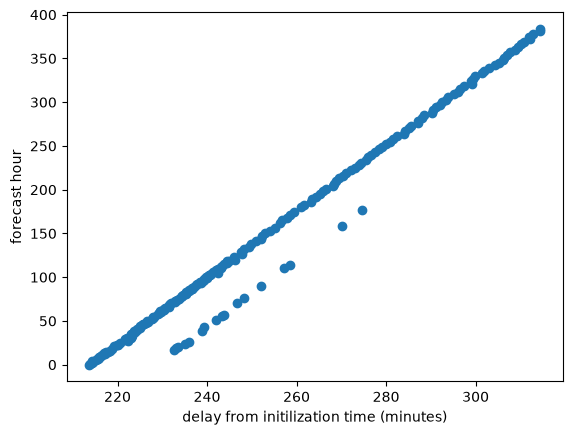

In [10]:
plt.scatter(delay.values, df_filtered['forecast_hour'].values)
plt.xlabel('delay from initilization time (minutes)')
plt.ylabel('forecast hour')
plt.show()

What's up with the occasional files that have an extra 10-15 minutes of delay?

### Now a loop
Now, do it in a loop of dates and loop of cycles:

In [11]:
dfs = []
regex_str = '.*(gfs\\.t)[0-9]{2}.*(z\\.pgrb2\\.0p25\\.f)[0-9]{3}'

for date in rand_dates:
    for cycle in ['00', '06', '12', '18']:
        response = client.list_objects_v2(
            Bucket='noaa-gfs-bdp-pds',
            Prefix=(f'gfs.{date}/{cycle}/atmos/gfs'))
        
        df = pd.DataFrame(response.get('Contents', []))
        filter = (df['Key'].str.match(regex_str)) * ~(df['Key'].str.contains(".idx"))
        df_filtered = df[filter].copy()

        df_filtered['forecast_hour'] = pd.to_numeric(df_filtered['Key'].str[-3:]).values
        init_date = pd.Timestamp(
            year=int(date[0:4]),
            month=int(date[4:6]),
            day=int(date[6:8]),
            hour=int(cycle),
            minute=0, second=0, tz='UTC')

        delay = (df_filtered['LastModified'] - init_date).dt.total_seconds() / 60
        df_filtered['delay'] = delay
        df_filtered['init_date'] = init_date
        df_filtered['cycle'] = cycle
        dfs.append(df_filtered)

df_all = pd.concat(dfs)


And plot it a few ways:

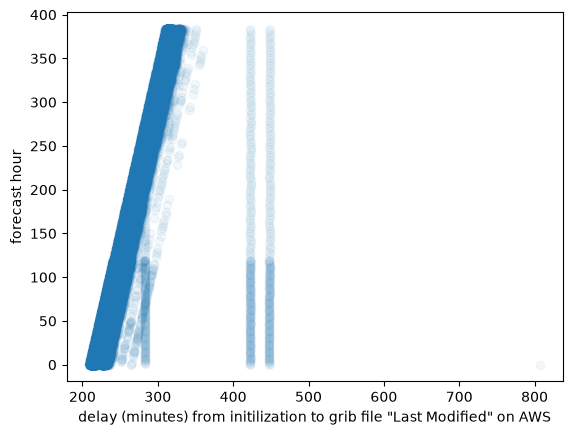

In [12]:
plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=0.05)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file "Last Modified" on AWS')
plt.show()

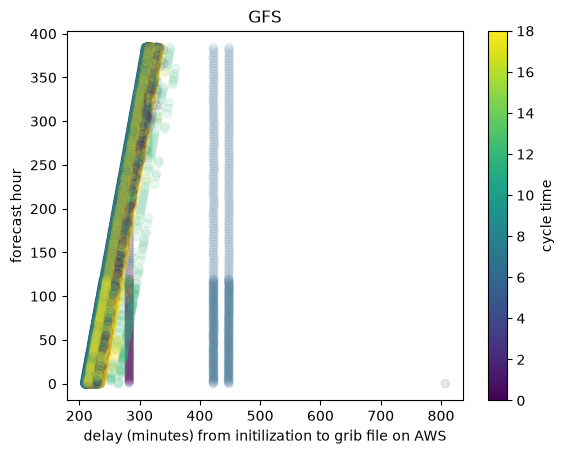

In [13]:
sc = plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=1, c=pd.to_numeric(df_all['cycle']))
cbar = plt.colorbar()
sc.set_alpha(0.1)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file on AWS')
cbar.ax.set_ylabel('cycle time')
plt.title('GFS')
plt.show()

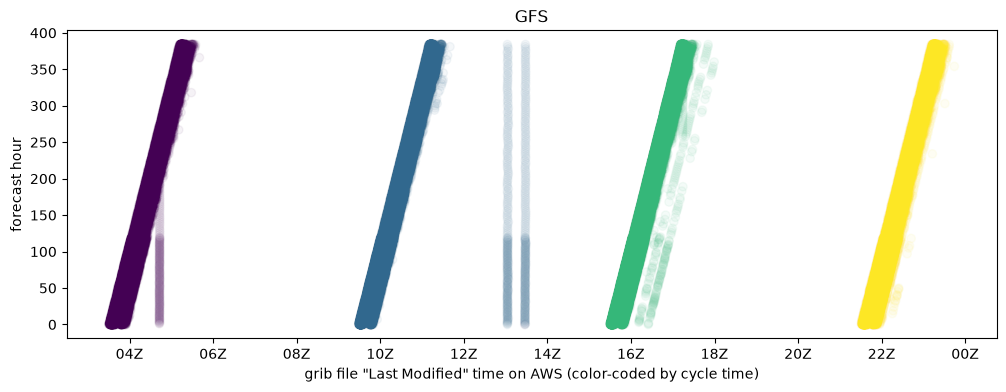

In [14]:
plt.figure(figsize=(12,4))
plt.scatter(pd.to_datetime(df_all['LastModified'].dt.time, format='%H:%M:%S'), df_all['forecast_hour'], alpha=0.05, c=pd.to_numeric(df_all['cycle']))
# plt.colorbar()
plt.ylabel('forecast hour')
plt.xlabel('grib file "Last Modified" time on AWS (color-coded by cycle time)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%HZ'))
plt.title('GFS')
plt.show()

### Linear Quantile Regressions

Now, let's calculate some linear quantile regressions:

(based on example at https://www.statsmodels.org/stable/examples/notebooks/generated/quantile_regression.html)

In [15]:
quantiles = [0.5, 0.95, 0.99]

In [16]:
slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df_all)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

Plot it and print the slopes and intercepts of the linear fits:

Intercepts (minutes after init)
{0.5: np.float64(214.6660784295141), 0.95: np.float64(230.08137474677716), 0.99: np.float64(233.6363531039976)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.2618300645557029), 0.95: np.float64(0.25649596999010416), 0.99: np.float64(0.2580422231140257)}


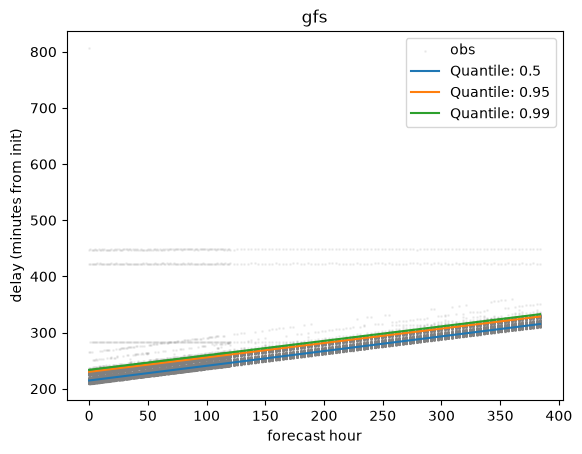

In [17]:

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)
plt.scatter(df_all['forecast_hour'], df_all['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df_all['forecast_hour'],
             df_all['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('gfs')
plt.show()


To calculate total time for 48h forecast using the 99th percentile intercept, with a 5% additional buffer, and 50th percentile slope:

In [18]:
example_delay = intercepts[0.99]*1.05 + 48 * slopes[0.5]
print(f'{example_delay} minutes')

257.88601385787126 minutes


## HRRR
Now, HRRR:

In [19]:
n = 200  # number of random dates
start = '2025-01-15'  # start of random dates
end = '2026-07-15'  # end of random dates
date_format = '%Y%m%d' #  e.g., 20250101

possible_dates = pd.date_range(start, end, freq='1D')
np.random.seed(42)
idx_random = np.random.permutation(len(possible_dates))[:n]
rand_dates = possible_dates[idx_random].strftime(date_format)
print(rand_dates)

Index(['20250710', '20250402', '20260111', '20250415', '20260118', '20250813',
       '20250711', '20250922', '20260617', '20250802',
       ...
       '20250927', '20250120', '20250511', '20250301', '20250821', '20260621',
       '20250131', '20250304', '20260516', '20260226'],
      dtype='str', length=200)


In [20]:
cycle = '00'
date = '20250914'

client = boto3.client('s3')
client.meta.events.register('choose-signer.s3.*', disable_signing)

response = client.list_objects_v2(
    Bucket='noaa-hrrr-bdp-pds',
    Prefix=(f'hrrr.{date}/conus/hrrr.'))

max = 10  # max number of files to print 
i = 1
for content in response.get('Contents', []):
    print(content['Key'], content['LastModified'])
    i += 1
    if i > max:
        break

df = pd.DataFrame(response.get('Contents', []))

hrrr.20250914/conus/hrrr.t00z.bufrsnd.tar.gz 2025-09-14 01:46:56+00:00
hrrr.20250914/conus/hrrr.t00z.class1.bufr.tm00 2025-09-14 01:46:47+00:00
hrrr.20250914/conus/hrrr.t00z.wrfnatf00.grib2 2025-09-14 00:52:08+00:00
hrrr.20250914/conus/hrrr.t00z.wrfnatf00.grib2.idx 2025-09-14 00:52:44+00:00
hrrr.20250914/conus/hrrr.t00z.wrfnatf01.grib2 2025-09-14 00:53:45+00:00
hrrr.20250914/conus/hrrr.t00z.wrfnatf01.grib2.idx 2025-09-14 00:54:24+00:00
hrrr.20250914/conus/hrrr.t00z.wrfnatf02.grib2 2025-09-14 00:55:16+00:00
hrrr.20250914/conus/hrrr.t00z.wrfnatf02.grib2.idx 2025-09-14 00:55:52+00:00
hrrr.20250914/conus/hrrr.t00z.wrfnatf03.grib2 2025-09-14 00:56:52+00:00
hrrr.20250914/conus/hrrr.t00z.wrfnatf03.grib2.idx 2025-09-14 00:57:29+00:00


In [21]:
# regex_str = '.*(hrrr\\.t)[0-9]{2}.*(z\\.wrfsfcf)[0-9]{2}'
regex_str = '.*wrfsfcf.*'
filter = (df['Key'].str.match(regex_str)) * ~(df['Key'].str.contains(".idx"))
df_filtered = df[filter].copy()
print(len(df_filtered))
df_filtered.head()

125


,Key,LastModified,ETag,ChecksumAlgorithm,ChecksumType,Size,StorageClass
198,hrrr.20250914/conus/hrrr.t00z.wrfsfcf00.grib2,2025-09-14 00:51:03+00:00,"""77355aab24967fa11dc3ad90199cb5f9""",[CRC32],FULL_OBJECT,147367917,STANDARD
200,hrrr.20250914/conus/hrrr.t00z.wrfsfcf01.grib2,2025-09-14 00:52:51+00:00,"""8fc470e96e864648edf1adc24d91d4fd""",[CRC32],FULL_OBJECT,151145441,STANDARD
202,hrrr.20250914/conus/hrrr.t00z.wrfsfcf02.grib2,2025-09-14 00:54:03+00:00,"""381920da224db0383955f7915a82d892""",[CRC32],FULL_OBJECT,150459479,STANDARD
204,hrrr.20250914/conus/hrrr.t00z.wrfsfcf03.grib2,2025-09-14 00:55:38+00:00,"""a3c61ae382362c7d05ad8df394a331fc""",[CRC32],FULL_OBJECT,151413466,STANDARD
206,hrrr.20250914/conus/hrrr.t00z.wrfsfcf04.grib2,2025-09-14 00:55:50+00:00,"""3557602dcaa83e8383e8428d54e5e289""",[CRC32],FULL_OBJECT,152573007,STANDARD


The original response from AWS only includes the first 1000 items, so we will need to pre-filter on cycle if we want more than ~4 cycles. And files end in ".grib2", so change the forecast hour filter acordingly. 

In [22]:
dfs = []
regex_str = '.*wrfsfcf.*'

for date in rand_dates:
    for cycle in ['00', '01', '02', '03', '04', '05',
                  '06', '07', '08', '09', '10', '11',
                  '12', '13', '14', '15', '16', '17',
                  '18', '19', '20', '21', '22', '23']:
        response = client.list_objects_v2(
            Bucket='noaa-hrrr-bdp-pds',
            Prefix=(f'hrrr.{date}/conus/hrrr.t{cycle}'))
        
        df = pd.DataFrame(response.get('Contents', []))
        filter = (df['Key'].str.match(regex_str)) * ~(df['Key'].str.contains(".idx"))
        df_filtered = df[filter].copy()

        df_filtered['forecast_hour'] = pd.to_numeric(df_filtered['Key'].str[-8:-6]).values
        init_date = pd.Timestamp(
            year=int(date[0:4]),
            month=int(date[4:6]),
            day=int(date[6:8]),
            hour=int(cycle),
            minute=0, second=0, tz='UTC')

        delay = (df_filtered['LastModified'] - init_date).dt.total_seconds() / 60
        df_filtered['delay'] = delay
        df_filtered['init_date'] = init_date
        df_filtered['cycle'] = cycle
        dfs.append(df_filtered)

df_all = pd.concat(dfs)

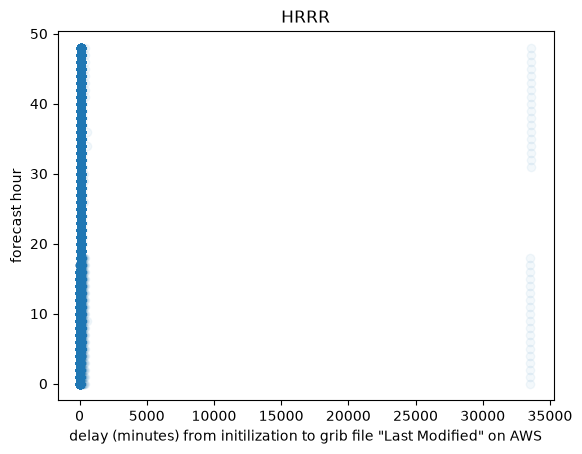

In [23]:
plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=0.05)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file "Last Modified" on AWS')
plt.title('HRRR')
plt.show()

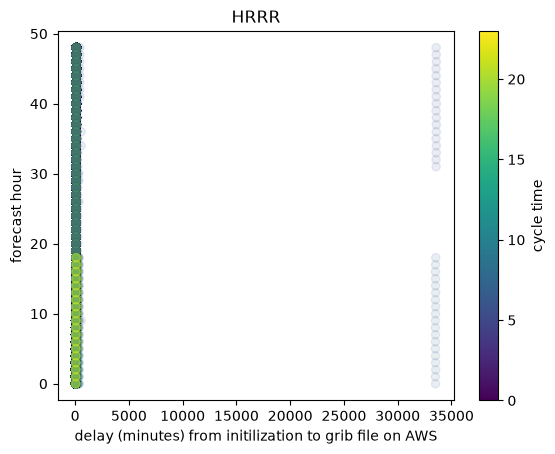

In [24]:
sc = plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=1, c=pd.to_numeric(df_all['cycle']))
cbar = plt.colorbar()
sc.set_alpha(0.1)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file on AWS')
cbar.ax.set_ylabel('cycle time')
plt.title('HRRR')
plt.show()

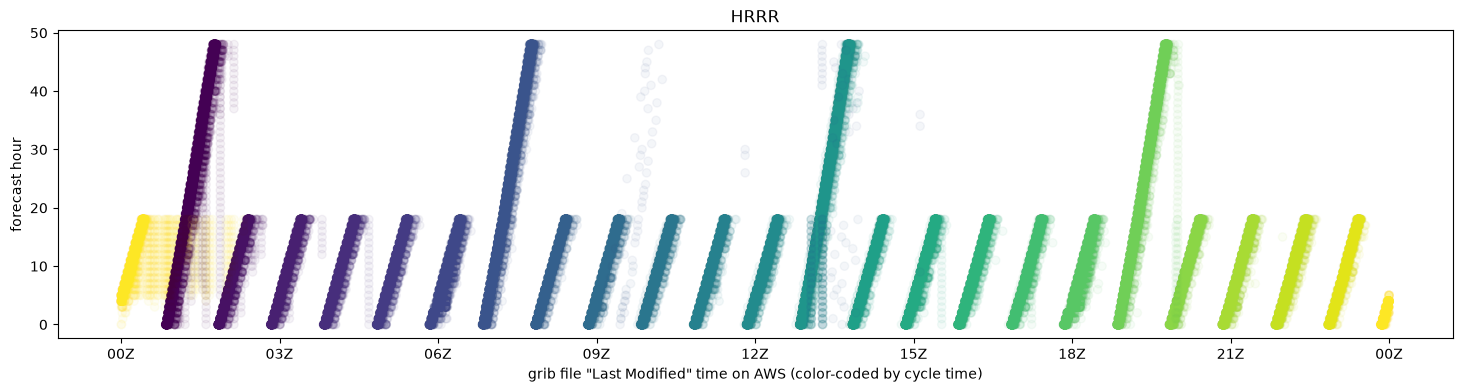

In [25]:
plt.figure(figsize=(18,4))
plt.scatter(pd.to_datetime(df_all['LastModified'].dt.time, format='%H:%M:%S'), df_all['forecast_hour'], alpha=0.05, c=pd.to_numeric(df_all['cycle']))
# plt.colorbar()
plt.ylabel('forecast hour')
plt.xlabel('grib file "Last Modified" time on AWS (color-coded by cycle time)')
plt.title('HRRR')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%HZ'))
plt.show()

Quantile regression, but filtered just to the 48h cycles:

In [38]:
df_filt = df_all[df_all['cycle'].isin(['00', '06', '12', '18'])].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

To calculate total time for 48h forecast using the 99th percentile intercept, with a 5% additional buffer, and 50th percentile slope:

In [39]:
example_delay = intercepts[0.99]*1.05 + 48 * slopes[0.50]
print(f'{example_delay} minutes')

122.18106061219834 minutes


Intercepts (minutes after init)
{0.5: np.float64(53.069590650939524), 0.95: np.float64(58.422727554756555), 0.99: np.float64(64.91191759528073)}
Slopes (minutes per forecast hour):
{0.5: np.float64(1.125490565357366), 0.95: np.float64(1.0848484587802942), 0.99: np.float64(1.1011897597923876)}


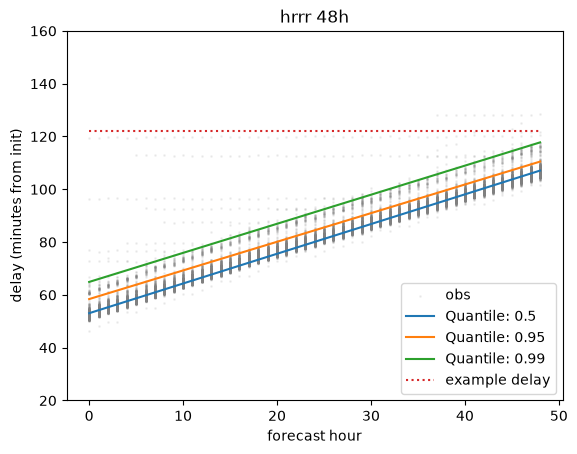

In [41]:
print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)

plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.plot([df['forecast_hour'].min(), df['forecast_hour'].max()],
         [example_delay, example_delay],
         label='example delay',
         linestyle=':')

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('hrrr 48h')
plt.ylim([20, 160])
plt.show()



And a regression on just the 18h cycles:

In [42]:
df_filt = df_all[~df_all['cycle'].isin(['00', '06', '12', '18'])].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

To calculate total time for 18h forecast using the 99th percentile intercept, with a 5% additional buffer, and 50th percentile slope:

In [43]:
example_delay = intercepts[0.99]*1.05 + 18 * slopes[0.5]
print(f'{example_delay} minutes')

97.05750911206286 minutes


Intercepts (minutes after init)
{0.5: np.float64(51.939992229624124), 0.95: np.float64(57.40476166632809), 0.99: np.float64(60.54999982622426)}
Slopes (minutes per forecast hour):
{0.5: np.float64(1.8600005163626325), 0.95: np.float64(1.965476169046691), 0.99: np.float64(3.666666575149052)}


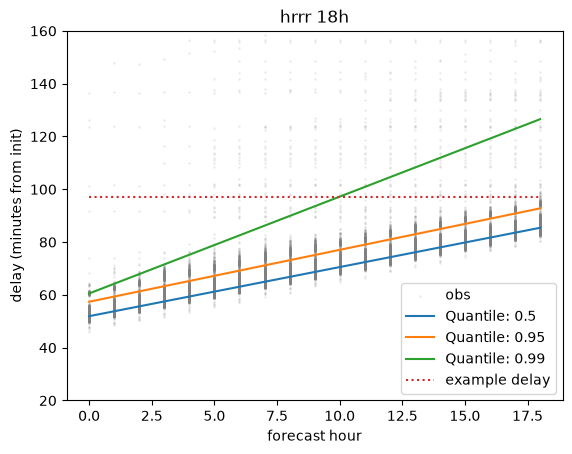

In [44]:
print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)

plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.plot([df['forecast_hour'].min(), df['forecast_hour'].max()],
         [example_delay, example_delay],
         label='example delay',
         linestyle=':')

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('hrrr 18h')
plt.ylim([20, 160])
plt.show()

## GEFS 0p25
Now GEFS 0p25:

In [45]:
n = 200  # number of random dates
start = '2025-01-15'  # start of random dates
end = '2026-07-15'  # end of random dates
date_format = '%Y%m%d' #  e.g., 20250101

possible_dates = pd.date_range(start, end, freq='1D')
np.random.seed(42)
idx_random = np.random.permutation(len(possible_dates))[:n]
rand_dates = possible_dates[idx_random].strftime(date_format)
print(rand_dates)

Index(['20250710', '20250402', '20260111', '20250415', '20260118', '20250813',
       '20250711', '20250922', '20260617', '20250802',
       ...
       '20250927', '20250120', '20250511', '20250301', '20250821', '20260621',
       '20250131', '20250304', '20260516', '20260226'],
      dtype='str', length=200)


In [46]:
cycle = '00'
date = '20250914'

client = boto3.client('s3')
client.meta.events.register('choose-signer.s3.*', disable_signing)

response = client.list_objects_v2(
    Bucket='noaa-gefs-pds',
    Prefix=(f'gefs.{date}/{cycle}/atmos/pgrb2sp25/gep01'))

max = 10  # max number of files to print 
i = 1
for content in response.get('Contents', []):
    print(content['Key'], content['LastModified'])
    i += 1
    if i > max:
        break

gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pgrb2s.0p25.f000 2025-09-14 03:47:07+00:00
gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pgrb2s.0p25.f000.idx 2025-09-14 03:47:08+00:00
gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pgrb2s.0p25.f003 2025-09-14 03:48:13+00:00
gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pgrb2s.0p25.f003.idx 2025-09-14 03:48:15+00:00
gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pgrb2s.0p25.f006 2025-09-14 03:49:25+00:00
gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pgrb2s.0p25.f006.idx 2025-09-14 03:49:26+00:00
gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pgrb2s.0p25.f009 2025-09-14 03:50:34+00:00
gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pgrb2s.0p25.f009.idx 2025-09-14 03:50:35+00:00
gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pgrb2s.0p25.f012 2025-09-14 03:51:45+00:00
gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pgrb2s.0p25.f012.idx 2025-09-14 03:51:46+00:00


In [47]:
df = pd.DataFrame(response.get('Contents', []))
df

,Key,LastModified,ETag,ChecksumAlgorithm,ChecksumType,Size,StorageClass
0,gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pg...,2025-09-14 03:47:07+00:00,"""a9d6a0a5b1614cb35e816c662bb68bc9""",[CRC32],FULL_OBJECT,12736111,STANDARD
1,gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pg...,2025-09-14 03:47:08+00:00,"""47e0a53c2e37a54a2bdbef28cabe00aa""",[CRC64NVME],FULL_OBJECT,1454,STANDARD
2,gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pg...,2025-09-14 03:48:13+00:00,"""bb83cc8502bdb1b01cc886bb6734a6c5""",[CRC32],FULL_OBJECT,17561180,STANDARD
3,gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pg...,2025-09-14 03:48:15+00:00,"""790361de6076d8f96a75bd6d261ac94e""",[CRC64NVME],FULL_OBJECT,2440,STANDARD
4,gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pg...,2025-09-14 03:49:25+00:00,"""1e7301cbebfd681954566bafdac10732""",[CRC32],FULL_OBJECT,17724436,STANDARD
...,...,...,...,...,...,...,...
157,gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pg...,2025-09-14 05:26:51+00:00,"""6101f6e062a40b2132058590740d8b68""",[CRC64NVME],FULL_OBJECT,2545,STANDARD
158,gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pg...,2025-09-14 05:26:52+00:00,"""035752c5d92d68463a9ecfcd5732281f""",[CRC32],FULL_OBJECT,16786155,STANDARD
159,gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pg...,2025-09-14 05:26:53+00:00,"""18172c62a2e908c4bac98a516920eab9""",[CRC64NVME],FULL_OBJECT,2545,STANDARD
160,gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pg...,2025-09-14 05:29:08+00:00,"""627c0e5b0c5304585286df4136eb7adf""",[CRC32],FULL_OBJECT,17417819,STANDARD


In [48]:
# regex_str = '.*(hrrr\\.t)[0-9]{2}.*(z\\.wrfsfcf)[0-9]{2}'
regex_str = '.*pgrb2.*'
filter = (df['Key'].str.match(regex_str)) * ~(df['Key'].str.contains(".idx"))
df_filtered = df[filter].copy()
print(len(df_filtered))
df_filtered.head()

81


,Key,LastModified,ETag,ChecksumAlgorithm,ChecksumType,Size,StorageClass
0,gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pg...,2025-09-14 03:47:07+00:00,"""a9d6a0a5b1614cb35e816c662bb68bc9""",[CRC32],FULL_OBJECT,12736111,STANDARD
2,gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pg...,2025-09-14 03:48:13+00:00,"""bb83cc8502bdb1b01cc886bb6734a6c5""",[CRC32],FULL_OBJECT,17561180,STANDARD
4,gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pg...,2025-09-14 03:49:25+00:00,"""1e7301cbebfd681954566bafdac10732""",[CRC32],FULL_OBJECT,17724436,STANDARD
6,gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pg...,2025-09-14 03:50:34+00:00,"""68550f96d38ae24f66a1b5c035f4685c""",[CRC32],FULL_OBJECT,16858572,STANDARD
8,gefs.20250914/00/atmos/pgrb2sp25/gep01.t00z.pg...,2025-09-14 03:51:45+00:00,"""2ea2eeb5a580d3a2e89780a6590c0d8f""",[CRC32],FULL_OBJECT,17016777,STANDARD


Get the average, which can't be calculated until all members are done.

In [50]:
dfs = []
regex_str = '.*pgrb2.*'

for date in rand_dates:
    for cycle in ['00', '06', '12', '18']:
        response = client.list_objects_v2(
            Bucket='noaa-gefs-pds',
            Prefix=(f'gefs.{date}/{cycle}/atmos/pgrb2sp25/geavg'))
        
        df = pd.DataFrame(response.get('Contents', []))
        filter = (df['Key'].str.match(regex_str)) * ~(df['Key'].str.contains(".idx"))
        df_filtered = df[filter].copy()

        df_filtered['forecast_hour'] = pd.to_numeric(df_filtered['Key'].str[-3:]).values
        init_date = pd.Timestamp(
            year=int(date[0:4]),
            month=int(date[4:6]),
            day=int(date[6:8]),
            hour=int(cycle),
            minute=0, second=0, tz='UTC')

        delay = (df_filtered['LastModified'] - init_date).dt.total_seconds() / 60
        df_filtered['delay'] = delay
        df_filtered['init_date'] = init_date
        df_filtered['cycle'] = cycle
        dfs.append(df_filtered)

df_all = pd.concat(dfs)

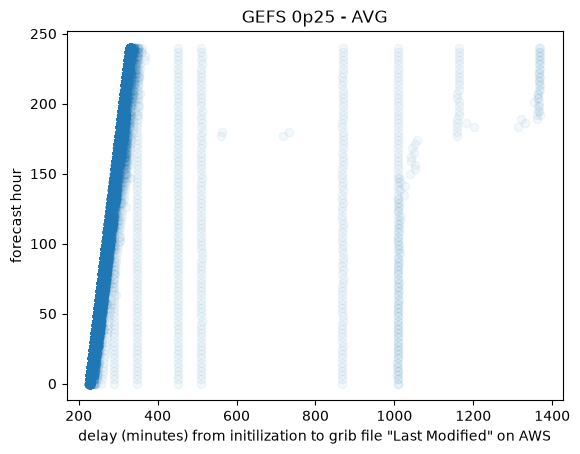

In [51]:
plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=0.05)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file "Last Modified" on AWS')
plt.title('GEFS 0p25 - AVG')
plt.show()

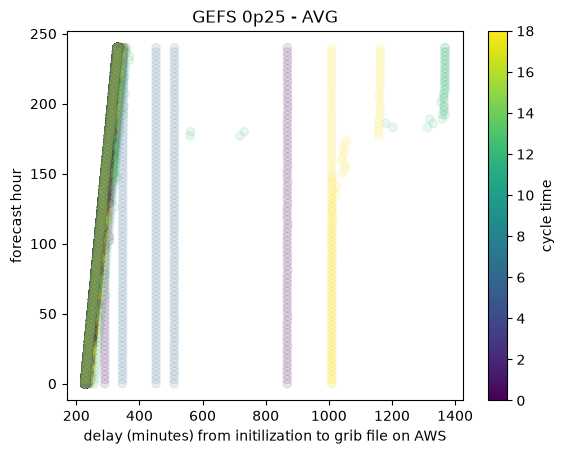

In [52]:
sc = plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=1, c=pd.to_numeric(df_all['cycle']))
cbar = plt.colorbar()
sc.set_alpha(0.1)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file on AWS')
cbar.ax.set_ylabel('cycle time')
plt.title('GEFS 0p25 - AVG')
plt.show()

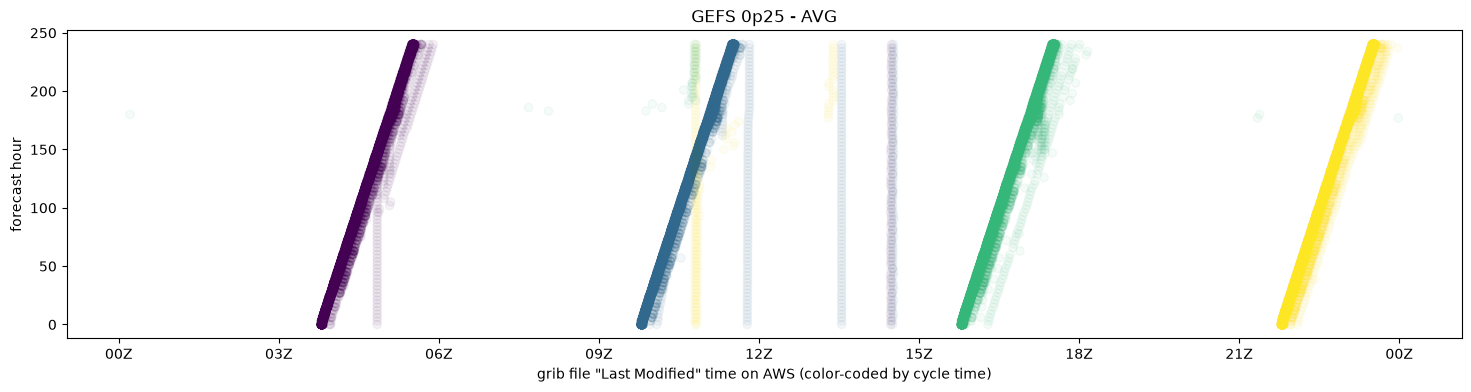

In [53]:
plt.figure(figsize=(18,4))
plt.scatter(pd.to_datetime(df_all['LastModified'].dt.time, format='%H:%M:%S'), df_all['forecast_hour'], alpha=0.05, c=pd.to_numeric(df_all['cycle']))
# plt.colorbar()
plt.ylabel('forecast hour')
plt.xlabel('grib file "Last Modified" time on AWS (color-coded by cycle time)')
plt.title('GEFS 0p25 - AVG')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%HZ'))
plt.show()

And a regression:

In [54]:
slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df_all)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

To calculate total time using the 99th percentile intercept, with a 5% additional buffer, and 50th percentile slope:

In [55]:
example_delay = intercepts[0.99]*1.05 + 240 * slopes[0.5]
print(f'{example_delay} minutes')

361.0160243165419 minutes


Intercepts (minutes after init)
{0.5: np.float64(227.09182712986987), 0.95: np.float64(230.28229139808806), 0.99: np.float64(244.99999905466822)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.43235843878808455), 0.95: np.float64(0.43350694307652876), 0.99: np.float64(0.4873873900923802)}


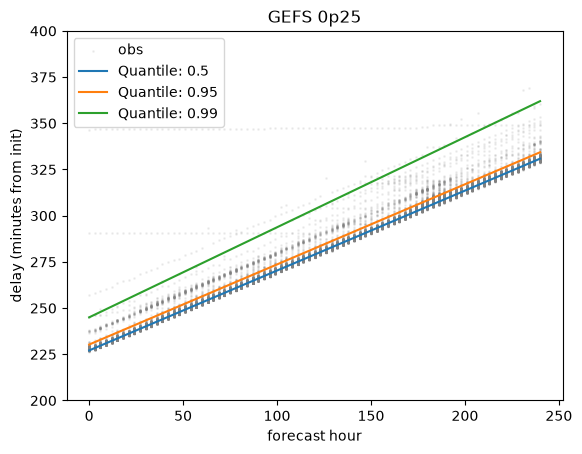

In [57]:

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)

plt.scatter(df_all['forecast_hour'], df_all['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df_all['forecast_hour'],
             df_all['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('GEFS 0p25')
plt.ylim([200, 400])
plt.show()

## GEFS 0p50
Now GEFS 0p50:

In [58]:
n = 200  # number of random dates
start = '2025-01-15'  # start of random dates
end = '2026-07-15'  # end of random dates
date_format = '%Y%m%d' #  e.g., 20250101

possible_dates = pd.date_range(start, end, freq='1D')
np.random.seed(42)
idx_random = np.random.permutation(len(possible_dates))[:n]
rand_dates = possible_dates[idx_random].strftime(date_format)
print(rand_dates)

Index(['20250710', '20250402', '20260111', '20250415', '20260118', '20250813',
       '20250711', '20250922', '20260617', '20250802',
       ...
       '20250927', '20250120', '20250511', '20250301', '20250821', '20260621',
       '20250131', '20250304', '20260516', '20260226'],
      dtype='str', length=200)


In [59]:
cycle = '00'
date = '20260714'

client = boto3.client('s3')
client.meta.events.register('choose-signer.s3.*', disable_signing)

response = client.list_objects_v2(
    Bucket='noaa-gefs-pds',
    Prefix=(f'gefs.{date}/{cycle}/atmos/pgrb2ap5/gep01'))

max = 10  # max number of files to print 
i = 1
for content in response.get('Contents', []):
    print(content['Key'], content['LastModified'])
    i += 1
    if i > max:
        break

gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgrb2a.0p50.f000 2026-07-14 03:46:49+00:00
gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgrb2a.0p50.f000.idx 2026-07-14 03:46:50+00:00
gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgrb2a.0p50.f003 2026-07-14 03:46:49+00:00
gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgrb2a.0p50.f003.idx 2026-07-14 03:46:50+00:00
gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgrb2a.0p50.f006 2026-07-14 03:47:56+00:00
gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgrb2a.0p50.f006.idx 2026-07-14 03:47:58+00:00
gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgrb2a.0p50.f009 2026-07-14 03:50:11+00:00
gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgrb2a.0p50.f009.idx 2026-07-14 03:50:12+00:00
gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgrb2a.0p50.f012 2026-07-14 03:51:19+00:00
gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgrb2a.0p50.f012.idx 2026-07-14 03:51:20+00:00


In [60]:
df = pd.DataFrame(response.get('Contents', []))
df

,Key,LastModified,ETag,ChecksumAlgorithm,ChecksumType,Size,StorageClass
0,gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgr...,2026-07-14 03:46:49+00:00,"""e8b7f137b257112428b4723bfc0e8fa2""",[CRC32],FULL_OBJECT,13921023,STANDARD
1,gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgr...,2026-07-14 03:46:50+00:00,"""5fe014de8c7bc7a6a9ea9e4b32df612c""",[CRC64NVME],FULL_OBJECT,3447,STANDARD
2,gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgr...,2026-07-14 03:46:49+00:00,"""8c603322e98f6b4b526f8533b151a25b""",[CRC32],FULL_OBJECT,15720406,STANDARD
3,gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgr...,2026-07-14 03:46:50+00:00,"""eaa63e3e813a276680f7a9144b457a07""",[CRC64NVME],FULL_OBJECT,4953,STANDARD
4,gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgr...,2026-07-14 03:47:56+00:00,"""5fc4607c156da396f8644688c65d3084""",[CRC32],FULL_OBJECT,15905619,STANDARD
...,...,...,...,...,...,...,...
357,gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgr...,2026-07-14 09:00:28+00:00,"""85ded8faad2c386a9401eee0ed3c9266""",[CRC64NVME],FULL_OBJECT,5151,STANDARD
358,gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgr...,2026-07-14 09:03:04+00:00,"""74df8d0467ba7c6786afe2eed0b95558""",[CRC32],FULL_OBJECT,15290230,STANDARD
359,gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgr...,2026-07-14 09:03:06+00:00,"""c596b0e22177a171da9aa60b4408ef9b""",[CRC64NVME],FULL_OBJECT,5151,STANDARD
360,gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgr...,2026-07-14 09:04:23+00:00,"""3333ab983b9e180994c436f20076b732""",[CRC32],FULL_OBJECT,15216447,STANDARD


In [61]:
# regex_str = '.*(hrrr\\.t)[0-9]{2}.*(z\\.wrfsfcf)[0-9]{2}'
regex_str = '.*pgrb2a.*'
filter = (df['Key'].str.match(regex_str)) * ~(df['Key'].str.contains(".idx"))
df_filtered = df[filter].copy()
print(len(df_filtered))
df_filtered.head()

181


,Key,LastModified,ETag,ChecksumAlgorithm,ChecksumType,Size,StorageClass
0,gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgr...,2026-07-14 03:46:49+00:00,"""e8b7f137b257112428b4723bfc0e8fa2""",[CRC32],FULL_OBJECT,13921023,STANDARD
2,gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgr...,2026-07-14 03:46:49+00:00,"""8c603322e98f6b4b526f8533b151a25b""",[CRC32],FULL_OBJECT,15720406,STANDARD
4,gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgr...,2026-07-14 03:47:56+00:00,"""5fc4607c156da396f8644688c65d3084""",[CRC32],FULL_OBJECT,15905619,STANDARD
6,gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgr...,2026-07-14 03:50:11+00:00,"""b4e1a8eb5dd568e3d57c1971a9de71fb""",[CRC32],FULL_OBJECT,15781384,STANDARD
8,gefs.20260714/00/atmos/pgrb2ap5/gep01.t00z.pgr...,2026-07-14 03:51:19+00:00,"""026c1832f804fb58b663c0720058186b""",[CRC32],FULL_OBJECT,15557986,STANDARD


Start with the first member, `'p01'`.

In [62]:
dfs = []
regex_str = '.*pgrb2a.*'

for date in rand_dates:
    for cycle in ['00', '06', '12', '18']:
        response = client.list_objects_v2(
            Bucket='noaa-gefs-pds',
            Prefix=(f'gefs.{date}/{cycle}/atmos/pgrb2ap5/gep01'))
        
        df = pd.DataFrame(response.get('Contents', []))
        filter = (df['Key'].str.match(regex_str)) * ~(df['Key'].str.contains(".idx"))
        df_filtered = df[filter].copy()

        df_filtered['forecast_hour'] = pd.to_numeric(df_filtered['Key'].str[-3:]).values
        init_date = pd.Timestamp(
            year=int(date[0:4]),
            month=int(date[4:6]),
            day=int(date[6:8]),
            hour=int(cycle),
            minute=0, second=0, tz='UTC')

        delay = (df_filtered['LastModified'] - init_date).dt.total_seconds() / 60
        df_filtered['delay'] = delay
        df_filtered['init_date'] = init_date
        df_filtered['cycle'] = cycle
        dfs.append(df_filtered)

df_all = pd.concat(dfs)

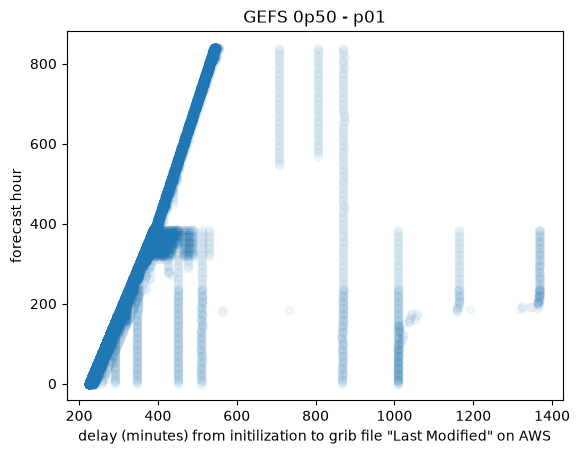

In [63]:
plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=0.05)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file "Last Modified" on AWS')
plt.title('GEFS 0p50 - p01')
plt.show()

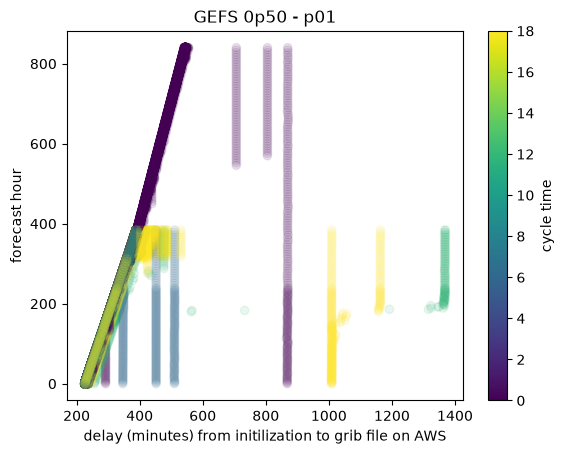

In [64]:
sc = plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=1, c=pd.to_numeric(df_all['cycle']))
cbar = plt.colorbar()
sc.set_alpha(0.1)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file on AWS')
cbar.ax.set_ylabel('cycle time')
plt.title('GEFS 0p50 - p01')
plt.show()

But based on browsing the AWS bucket and looking at https://dynamical.org/research/when-the-forecast-is-ready/, some members clearly take longer. Let's look at the last member, `'p30'`:

In [65]:
dfs = []
regex_str = '.*pgrb2a.*'

for date in rand_dates:
    for cycle in ['00', '06', '12', '18']:
        response = client.list_objects_v2(
            Bucket='noaa-gefs-pds',
            Prefix=(f'gefs.{date}/{cycle}/atmos/pgrb2ap5/gep30'))
        
        df = pd.DataFrame(response.get('Contents', []))
        filter = (df['Key'].str.match(regex_str)) * ~(df['Key'].str.contains(".idx"))
        df_filtered = df[filter].copy()

        df_filtered['forecast_hour'] = pd.to_numeric(df_filtered['Key'].str[-3:]).values
        init_date = pd.Timestamp(
            year=int(date[0:4]),
            month=int(date[4:6]),
            day=int(date[6:8]),
            hour=int(cycle),
            minute=0, second=0, tz='UTC')

        delay = (df_filtered['LastModified'] - init_date).dt.total_seconds() / 60
        df_filtered['delay'] = delay
        df_filtered['init_date'] = init_date
        df_filtered['cycle'] = cycle
        dfs.append(df_filtered)

df_all = pd.concat(dfs)


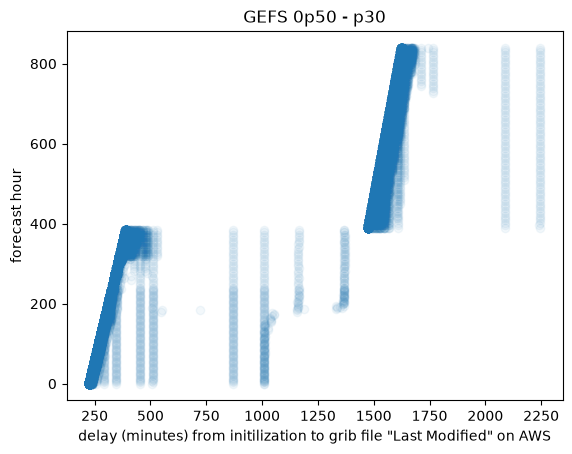

In [66]:
plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=0.05)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file "Last Modified" on AWS')
plt.title('GEFS 0p50 - p30')
plt.show()


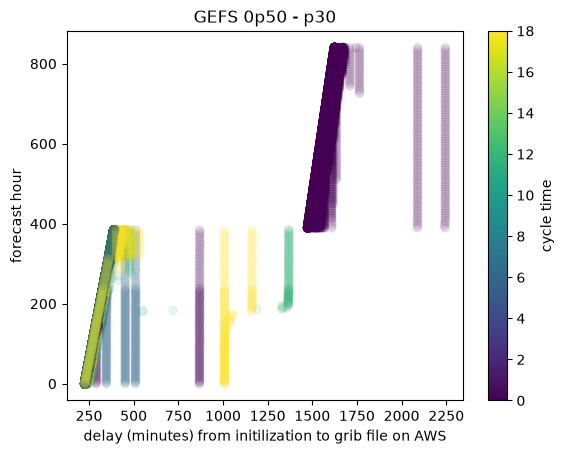

In [67]:

sc = plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=1, c=pd.to_numeric(df_all['cycle']))
cbar = plt.colorbar()
sc.set_alpha(0.1)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file on AWS')
cbar.ax.set_ylabel('cycle time')
plt.title('GEFS 0p50 - p30')
plt.show()


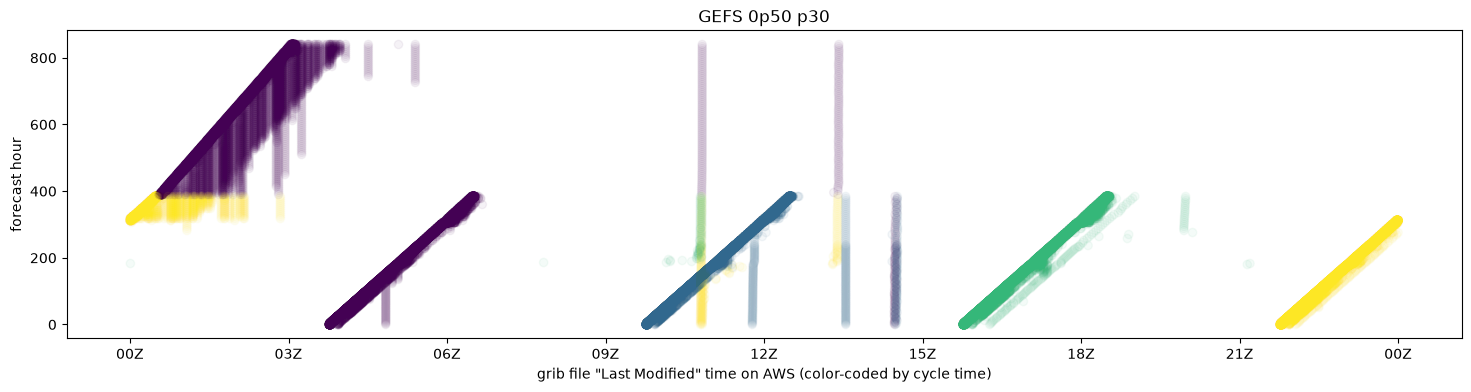

In [68]:
plt.figure(figsize=(18,4))
plt.scatter(pd.to_datetime(df_all['LastModified'].dt.time, format='%H:%M:%S'), df_all['forecast_hour'], alpha=0.05, c=pd.to_numeric(df_all['cycle']))
# plt.colorbar()
plt.ylabel('forecast hour')
plt.xlabel('grib file "Last Modified" time on AWS (color-coded by cycle time)')
plt.title('GEFS 0p50 p30')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%HZ'))
plt.show()

And a regression, but just for the 3h step portion:

Intercepts (minutes after init)
{0.5: np.float64(225.89722435660389), 0.95: np.float64(230.90048946984678), 0.99: np.float64(243.43333305091815)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.4300925691696653), 0.95: np.float64(0.41781045934535066), 0.99: np.float64(0.4821894281727633)}


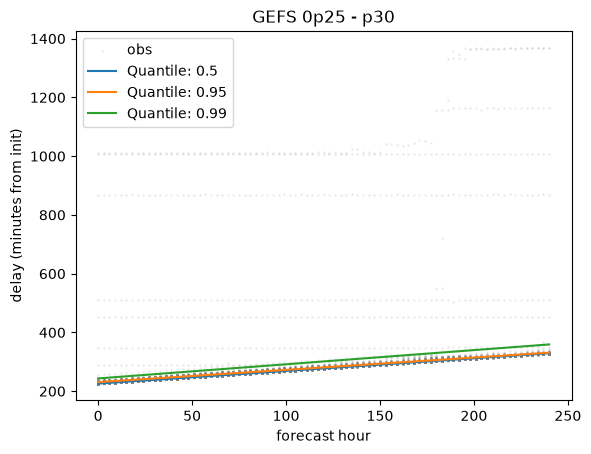

In [69]:
df_filt = df_all[df_all['forecast_hour'] <= 240].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)

plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('GEFS 0p25 - p30')
plt.show()

Look at the ensemble average, which can't be calculated until all 30 members are run, so it's presumably one of the last things to be published:

In [70]:
dfs = []
regex_str = '.*pgrb2a.*'

for date in rand_dates:
    for cycle in ['00', '06', '12', '18']:
        response = client.list_objects_v2(
            Bucket='noaa-gefs-pds',
            Prefix=(f'gefs.{date}/{cycle}/atmos/pgrb2ap5/geavg'))
        
        df = pd.DataFrame(response.get('Contents', []))
        filter = (df['Key'].str.match(regex_str)) * ~(df['Key'].str.contains(".idx"))
        df_filtered = df[filter].copy()

        df_filtered['forecast_hour'] = pd.to_numeric(df_filtered['Key'].str[-3:]).values
        init_date = pd.Timestamp(
            year=int(date[0:4]),
            month=int(date[4:6]),
            day=int(date[6:8]),
            hour=int(cycle),
            minute=0, second=0, tz='UTC')

        delay = (df_filtered['LastModified'] - init_date).dt.total_seconds() / 60
        df_filtered['delay'] = delay
        df_filtered['init_date'] = init_date
        df_filtered['cycle'] = cycle
        dfs.append(df_filtered)

df_all = pd.concat(dfs)


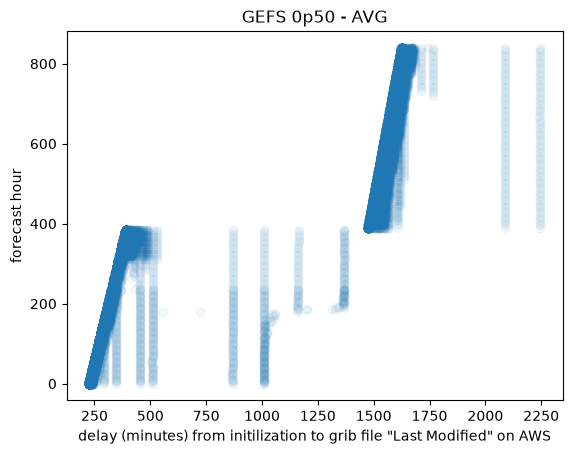

In [71]:
plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=0.05)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file "Last Modified" on AWS')
plt.title('GEFS 0p50 - AVG')
plt.show()


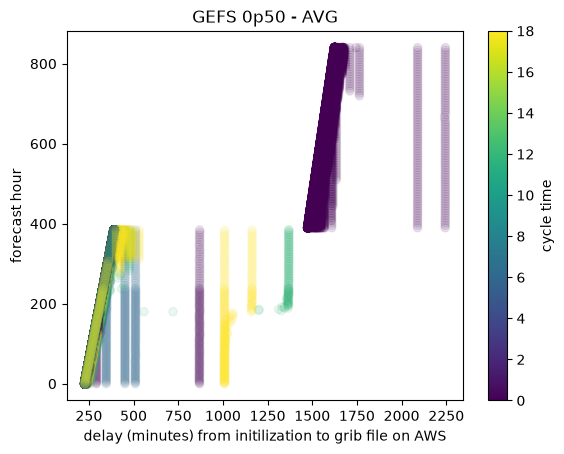

In [72]:
sc = plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=1, c=pd.to_numeric(df_all['cycle']))
cbar = plt.colorbar()
sc.set_alpha(0.1)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file on AWS')
cbar.ax.set_ylabel('cycle time')
plt.title('GEFS 0p50 - AVG')
plt.show()

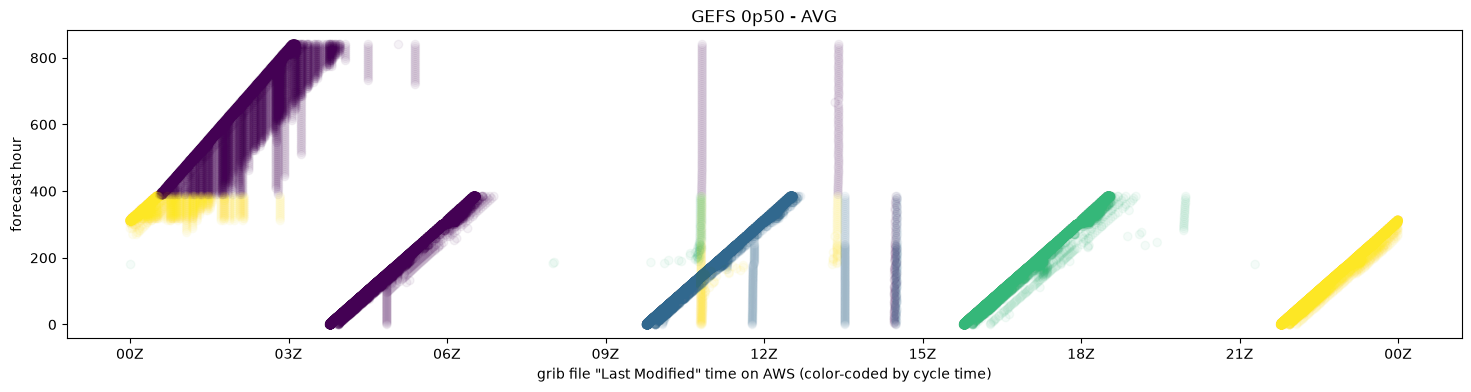

In [73]:
plt.figure(figsize=(18,4))
plt.scatter(pd.to_datetime(df_all['LastModified'].dt.time, format='%H:%M:%S'), df_all['forecast_hour'], alpha=0.05, c=pd.to_numeric(df_all['cycle']))
# plt.colorbar()
plt.ylabel('forecast hour')
plt.xlabel('grib file "Last Modified" time on AWS (color-coded by cycle time)')
plt.title('GEFS 0p50 - AVG')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%HZ'))
plt.show()

Regression for the 3-hourly portion:

Intercepts (minutes after init)
{0.5: np.float64(226.36333266316012), 0.95: np.float64(236.26666693732187), 0.99: np.float64(243.6833334697833)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.4322222282117115), 0.95: np.float64(0.4006944177502598), 0.99: np.float64(0.48888884066210303)}


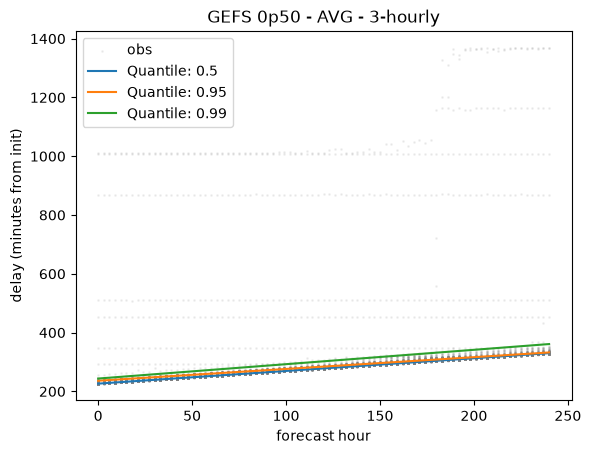

In [74]:
df_filt = df_all[df_all['forecast_hour'] <= 240].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)

plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('GEFS 0p50 - AVG - 3-hourly')
plt.show()

The 6-hourly standard portion:

Intercepts (minutes after init)
{0.5: np.float64(227.6039678319597), 0.95: np.float64(171.23174755322327), 0.99: np.float64(256.60625322662884)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.4271164025944708), 0.95: np.float64(0.660846553109705), 0.99: np.float64(0.6732638783758699)}


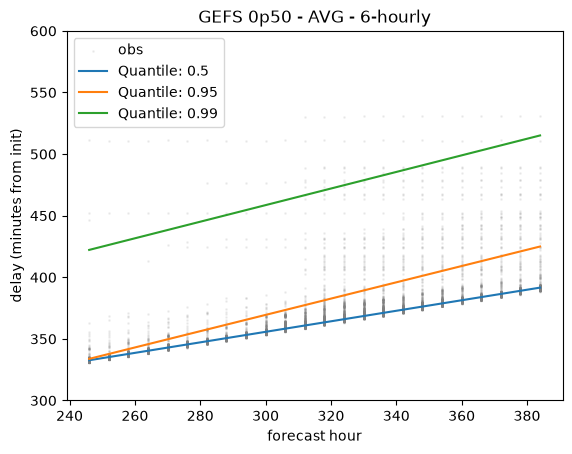

In [78]:
df_filt = df_all[((df_all['forecast_hour'] > 240) & 
                 (df_all['forecast_hour'] <= 384))].copy()
df = df_filt

quantiles = [0.5, 0.95, 0.99]
slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('GEFS 0p50 - AVG - 6-hourly')
plt.ylim([300, 600])
plt.show()

And 6-hourly extended:

Intercepts (minutes after init)
{0.5: np.float64(1345.8010398083618), 0.95: np.float64(1420.2997333601588), 0.99: np.float64(1424.627268379029)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.33420139201753823), 0.95: np.float64(0.30353942105133774), 0.99: np.float64(0.47121213492519815)}


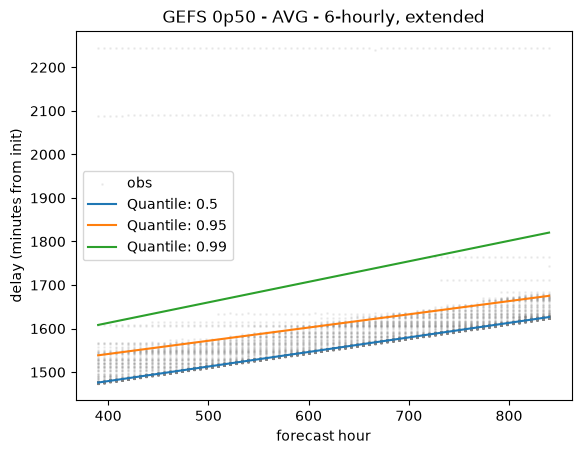

In [76]:
df_filt = df_all[(df_all['forecast_hour'] > 384)].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('GEFS 0p50 - AVG - 6-hourly, extended')
plt.show()

## IFS oper and scda

For now, just look at files from before 2026-05-12 due to IFS product name change (see https://github.com/williamhobbs/hefty/issues/50).

In [79]:
n = 200  # number of random dates
start = '2025-01-15'  # start of random dates
end = '2026-05-01'  # end of random dates 
date_format = '%Y%m%d' #  e.g., 20250101

possible_dates = pd.date_range(start, end, freq='1D')
np.random.seed(42)
idx_random = np.random.permutation(len(possible_dates))[:n]
rand_dates = possible_dates[idx_random].strftime(date_format)
print(rand_dates)

Index(['20250311', '20250329', '20250217', '20251020', '20250916', '20260130',
       '20250814', '20250124', '20250521', '20250326',
       ...
       '20260224', '20260222', '20260112', '20260420', '20250220', '20250603',
       '20260114', '20260129', '20251016', '20251010'],
      dtype='str', length=200)


In [80]:
cycle = '00'
date = '20250914'

client = boto3.client('s3')
client.meta.events.register('choose-signer.s3.*', disable_signing)

response = client.list_objects_v2(
    Bucket='ecmwf-forecasts',
    Prefix=(f'{date}/{cycle}z/ifs/0p25/oper/'),
    )

max = 10  # max number of files to print 
i = 1
for content in response.get('Contents', []):
    print(content['Key'], content['LastModified'])
    i += 1
    if i > max:
        break

20250914/00z/ifs/0p25/oper/20250914000000-0h-oper-fc.grib2 2025-09-14 08:34:01+00:00
20250914/00z/ifs/0p25/oper/20250914000000-0h-oper-fc.index 2025-09-14 08:34:01+00:00
20250914/00z/ifs/0p25/oper/20250914000000-102h-oper-fc.grib2 2025-09-14 08:34:18+00:00
20250914/00z/ifs/0p25/oper/20250914000000-102h-oper-fc.index 2025-09-14 08:34:18+00:00
20250914/00z/ifs/0p25/oper/20250914000000-105h-oper-fc.grib2 2025-09-14 08:34:18+00:00
20250914/00z/ifs/0p25/oper/20250914000000-105h-oper-fc.index 2025-09-14 08:34:19+00:00
20250914/00z/ifs/0p25/oper/20250914000000-108h-oper-fc.grib2 2025-09-14 08:34:19+00:00
20250914/00z/ifs/0p25/oper/20250914000000-108h-oper-fc.index 2025-09-14 08:34:19+00:00
20250914/00z/ifs/0p25/oper/20250914000000-111h-oper-fc.grib2 2025-09-14 08:34:20+00:00
20250914/00z/ifs/0p25/oper/20250914000000-111h-oper-fc.index 2025-09-14 08:34:20+00:00


In [81]:
df = pd.DataFrame(response.get('Contents', []))
df

,Key,LastModified,ETag,ChecksumAlgorithm,ChecksumType,Size,StorageClass
0,20250914/00z/ifs/0p25/oper/20250914000000-0h-o...,2025-09-14 08:34:01+00:00,"""e0044ec6abf43200c4e720953dab8b6d""",[CRC64NVME],FULL_OBJECT,117510997,INTELLIGENT_TIERING
1,20250914/00z/ifs/0p25/oper/20250914000000-0h-o...,2025-09-14 08:34:01+00:00,"""eee1f8c3734d32ac54ff85ad1cc3daa4""",[CRC64NVME],FULL_OBJECT,34686,STANDARD
2,20250914/00z/ifs/0p25/oper/20250914000000-102h...,2025-09-14 08:34:18+00:00,"""dfeb386ca5e98f12dedfd517a6ba95fc""",[CRC64NVME],FULL_OBJECT,126127284,INTELLIGENT_TIERING
3,20250914/00z/ifs/0p25/oper/20250914000000-102h...,2025-09-14 08:34:18+00:00,"""59bfdf0755e64ee0c973f43e8e57305a""",[CRC64NVME],FULL_OBJECT,34454,STANDARD
4,20250914/00z/ifs/0p25/oper/20250914000000-105h...,2025-09-14 08:34:18+00:00,"""187b6f1a04875344ee13095a1e914228""",[CRC64NVME],FULL_OBJECT,127131368,INTELLIGENT_TIERING
...,...,...,...,...,...,...,...
168,20250914/00z/ifs/0p25/oper/20250914000000-99h-...,2025-09-14 08:34:17+00:00,"""9dd4820c8467a21b9c0cd05a5dcb538a""",[CRC64NVME],FULL_OBJECT,34297,STANDARD
169,20250914/00z/ifs/0p25/oper/20250914000000-9h-o...,2025-09-14 08:34:03+00:00,"""314795d2ca02757f1953ec542ad6b9d9""",[CRC64NVME],FULL_OBJECT,127328038,INTELLIGENT_TIERING
170,20250914/00z/ifs/0p25/oper/20250914000000-9h-o...,2025-09-14 08:34:03+00:00,"""c6827773cffe79b92420cb06db854889""",[CRC64NVME],FULL_OBJECT,34141,STANDARD
171,20250914/00z/ifs/0p25/oper/LICENCE.txt,2025-09-14 08:34:02+00:00,"""0078c4dd3fa92595b81fb4900df7a56d""",[CRC64NVME],FULL_OBJECT,108,STANDARD


In [82]:
filter = (df['Key'].str.contains("fc.grib2"))
df_filtered = df[filter].copy()
print(len(df_filtered))
df_filtered.head()

85


,Key,LastModified,ETag,ChecksumAlgorithm,ChecksumType,Size,StorageClass
0,20250914/00z/ifs/0p25/oper/20250914000000-0h-o...,2025-09-14 08:34:01+00:00,"""e0044ec6abf43200c4e720953dab8b6d""",[CRC64NVME],FULL_OBJECT,117510997,INTELLIGENT_TIERING
2,20250914/00z/ifs/0p25/oper/20250914000000-102h...,2025-09-14 08:34:18+00:00,"""dfeb386ca5e98f12dedfd517a6ba95fc""",[CRC64NVME],FULL_OBJECT,126127284,INTELLIGENT_TIERING
4,20250914/00z/ifs/0p25/oper/20250914000000-105h...,2025-09-14 08:34:18+00:00,"""187b6f1a04875344ee13095a1e914228""",[CRC64NVME],FULL_OBJECT,127131368,INTELLIGENT_TIERING
6,20250914/00z/ifs/0p25/oper/20250914000000-108h...,2025-09-14 08:34:19+00:00,"""c92cba31b6332d3916ed177077736c75""",[CRC64NVME],FULL_OBJECT,127696359,INTELLIGENT_TIERING
8,20250914/00z/ifs/0p25/oper/20250914000000-111h...,2025-09-14 08:34:20+00:00,"""867f12acd6a18d8ceec0acd41e95c9c1""",[CRC64NVME],FULL_OBJECT,127059406,INTELLIGENT_TIERING


In [83]:
df_filtered['Key'].str.split('-', expand=True)[1].str[0:-1]

0        0
2      102
4      105
6      108
8      111
      ... 
161     90
163     93
165     96
167     99
169      9
Name: 1, Length: 85, dtype: str

Add extra dates around Oct 1, 2025, where it looks like ECMWF changed the schedule.

In [84]:
rand_dates = rand_dates.append(pd.date_range('2025-09-25', '2025-10-05', freq='1D').strftime(date_format))

In [85]:
dfs = []

for date in rand_dates:
    for cycle in ['00', '06', '12', '18']:
        if cycle in ['00', '12']:
            response = client.list_objects_v2(
                Bucket='ecmwf-forecasts',
                Prefix=(f'{date}/{cycle}z/ifs/0p25/oper/'),
                )
        else:
            response = client.list_objects_v2(
                Bucket='ecmwf-forecasts',
                Prefix=(f'{date}/{cycle}z/ifs/0p25/scda/'),
                )
        
        df = pd.DataFrame(response.get('Contents', []))
        filter = (df['Key'].str.contains("fc.grib2"))
        df_filtered = df[filter].copy()

        # split filenames with "-" delimeter, take the second column drop the last character, convert to number
        df_filtered['forecast_hour'] = pd.to_numeric(df_filtered['Key'].str.split('-', expand=True)[1].str[0:-1]).values
        init_date = pd.Timestamp(
            year=int(date[0:4]),
            month=int(date[4:6]),
            day=int(date[6:8]),
            hour=int(cycle),
            minute=0, second=0, tz='UTC')

        delay = (df_filtered['LastModified'] - init_date).dt.total_seconds() / 60
        df_filtered['delay'] = delay
        df_filtered['init_date'] = init_date
        df_filtered['cycle'] = cycle
        dfs.append(df_filtered)

df_all = pd.concat(dfs)

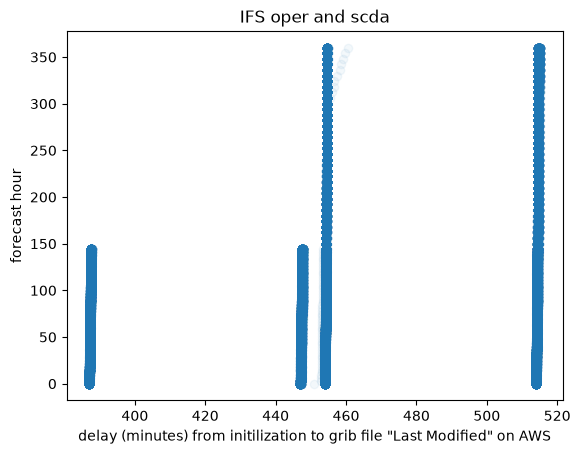

In [86]:
plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=0.05)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file "Last Modified" on AWS')
plt.title('IFS oper and scda')
plt.show()

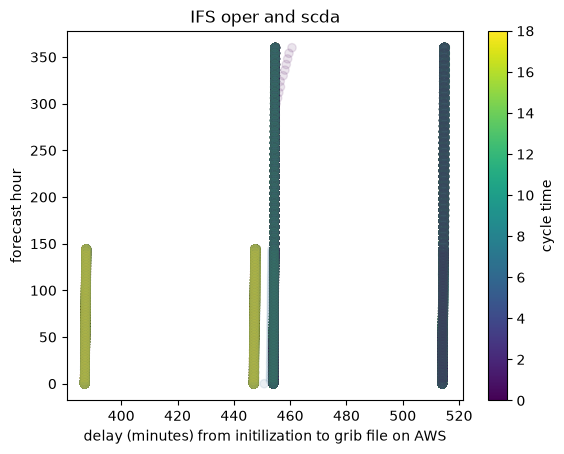

In [87]:
sc = plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=1, c=pd.to_numeric(df_all['cycle']))
cbar = plt.colorbar()
sc.set_alpha(0.1)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file on AWS')
cbar.ax.set_ylabel('cycle time')
plt.title('IFS oper and scda')
plt.show()

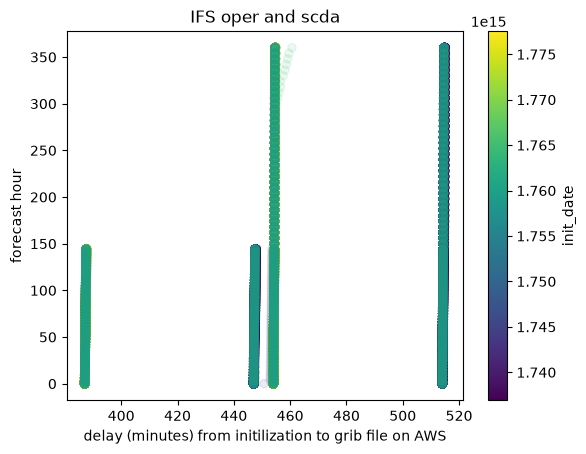

In [88]:
sc = plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=1, c=df_all['init_date'])
cbar = plt.colorbar()
# cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y%m%d'))
sc.set_alpha(0.1)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file on AWS')
cbar.ax.set_ylabel('init_date')
plt.title('IFS oper and scda')
plt.show()

A plot of delay by date. Approx Oct 1 2025, ECMWF removed the 1hr extra delay in releasing files. Descriptoin changed sometime between Nov 6 [1] and Nov 22 [2] 2025, but the changes to the ECMWF open data website are often delayed. Maybe it corresponded with this press release [3]?

[1] https://web.archive.org/web/20251106132450/https://www.ecmwf.int/en/forecasts/datasets/open-data

[2] https://web.archive.org/web/20251122204201/https://www.ecmwf.int/en/forecasts/datasets/open-data

[3] https://www.ecmwf.int/en/about/media-centre/news/2025/ecmwf-makes-its-entire-real-time-catalogue-open-all

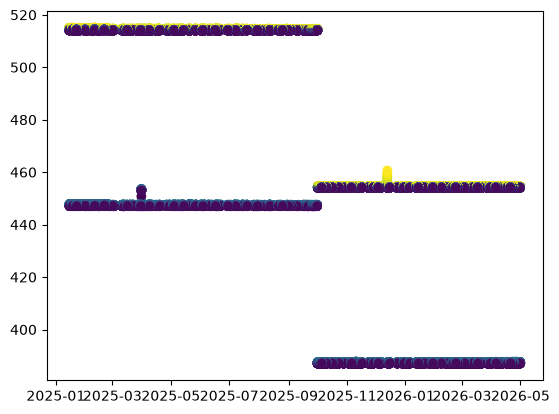

In [89]:
sc = plt.scatter(df_all['init_date'], df_all['delay'], alpha=1, c=df_all['forecast_hour'])

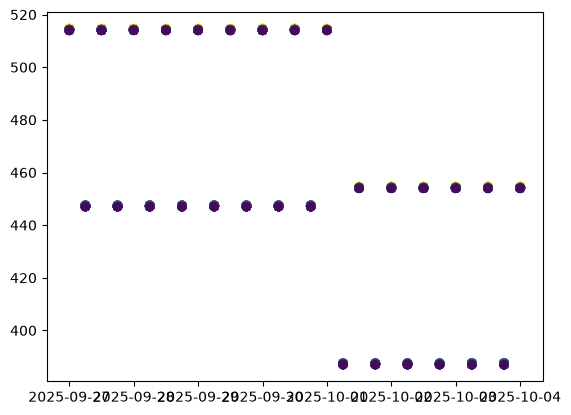

In [90]:
df_filt = df_all[(df_all['init_date'] >= '2025-09-27') & (df_all['init_date'] <= '2025-10-04')].copy()
sc = plt.scatter(df_filt['init_date'], df_filt['delay'], alpha=1, c=df_filt['forecast_hour'])


Looks like the change in schedule does occur on Oct 1, 2025.

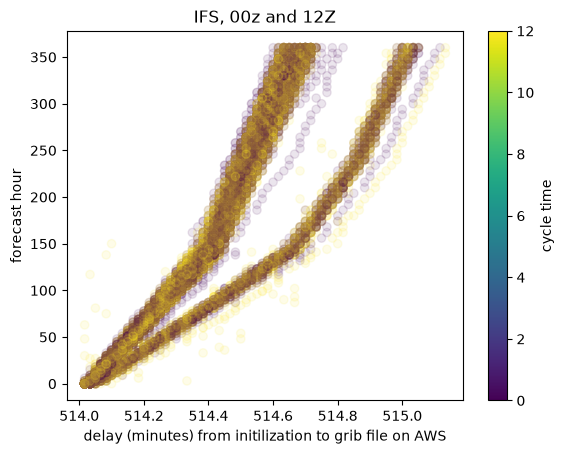

In [91]:
df_filt = df_all[((df_all['init_date'] < '2025-10-01') &
                  (df_all['cycle'].isin(['00', '12'])))].copy()

sc = plt.scatter(df_filt['delay'], df_filt['forecast_hour'], alpha=1, c=pd.to_numeric(df_filt['cycle']))
cbar = plt.colorbar()
sc.set_alpha(0.1)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file on AWS')
cbar.ax.set_ylabel('cycle time')
plt.title('IFS, 00z and 12Z')
plt.show()

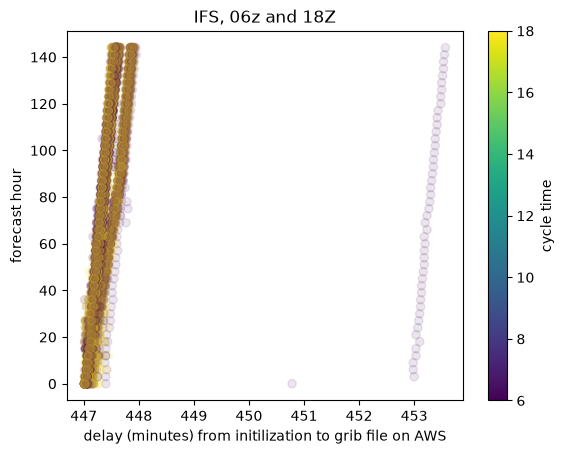

In [92]:
df_filt = df_all[((df_all['init_date'] < '2025-10-01') &
                  (df_all['cycle'].isin(['06', '18'])))].copy()

sc = plt.scatter(df_filt['delay'], df_filt['forecast_hour'], alpha=1, c=pd.to_numeric(df_filt['cycle']))
cbar = plt.colorbar()
sc.set_alpha(0.1)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file on AWS')
cbar.ax.set_ylabel('cycle time')
plt.title('IFS, 06z and 18Z')
plt.show()

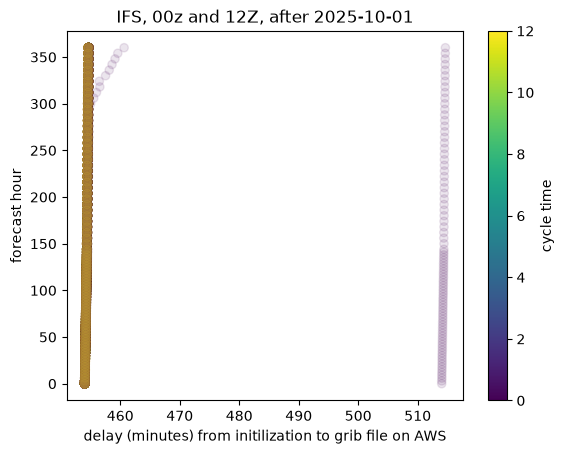

In [93]:
df_filt = df_all[((df_all['init_date'] >= '2025-10-01') &
                  (df_all['cycle'].isin(['00', '12'])))].copy()

sc = plt.scatter(df_filt['delay'], df_filt['forecast_hour'], alpha=1, c=pd.to_numeric(df_filt['cycle']))
cbar = plt.colorbar()
sc.set_alpha(0.1)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file on AWS')
cbar.ax.set_ylabel('cycle time')
plt.title('IFS, 00z and 12Z, after 2025-10-01')
plt.show()

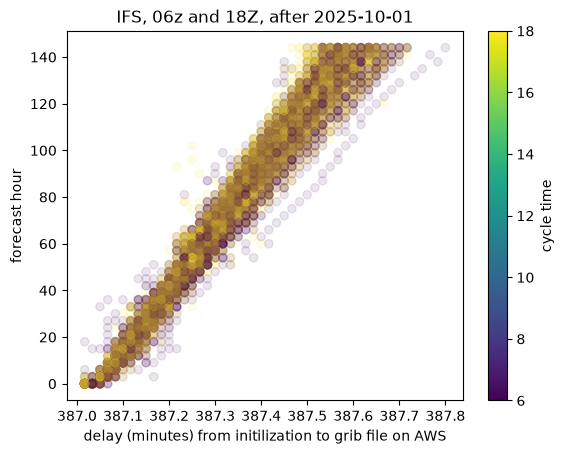

In [94]:
df_filt = df_all[((df_all['init_date'] >= '2025-10-01') &
                  (df_all['cycle'].isin(['06', '18'])))].copy()

sc = plt.scatter(df_filt['delay'], df_filt['forecast_hour'], alpha=1, c=pd.to_numeric(df_filt['cycle']))
cbar = plt.colorbar()
sc.set_alpha(0.1)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file on AWS')
cbar.ax.set_ylabel('cycle time')
plt.title('IFS, 06z and 18Z, after 2025-10-01')
plt.show()

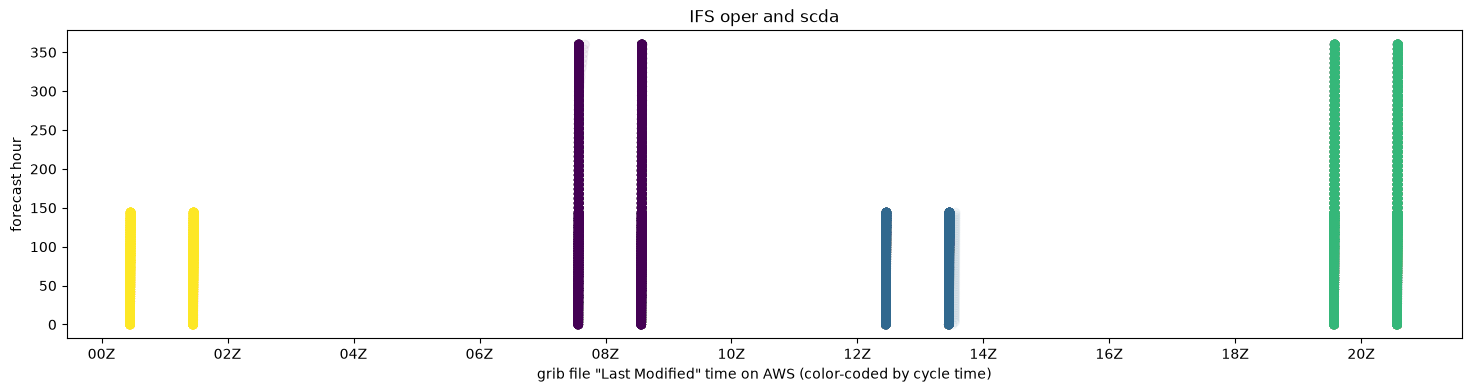

In [95]:
plt.figure(figsize=(18,4))
plt.scatter(pd.to_datetime(df_all['LastModified'].dt.time, format='%H:%M:%S'), df_all['forecast_hour'], alpha=0.05, c=pd.to_numeric(df_all['cycle']))
# plt.colorbar()
plt.ylabel('forecast hour')
plt.xlabel('grib file "Last Modified" time on AWS (color-coded by cycle time)')
plt.title('IFS oper and scda')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%HZ'))
plt.show()

Calculate delays for 00z and 12z cycles, 3-hourly steps (<= 144h)

Intercepts (minutes after init)
{0.5: np.float64(514.0342129655351), 0.95: np.float64(514.0576930704802), 0.99: np.float64(514.0761917372162)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.002631558667342268), 0.95: np.float64(0.004273334373502675), 0.99: np.float64(0.0043650618324376856)}


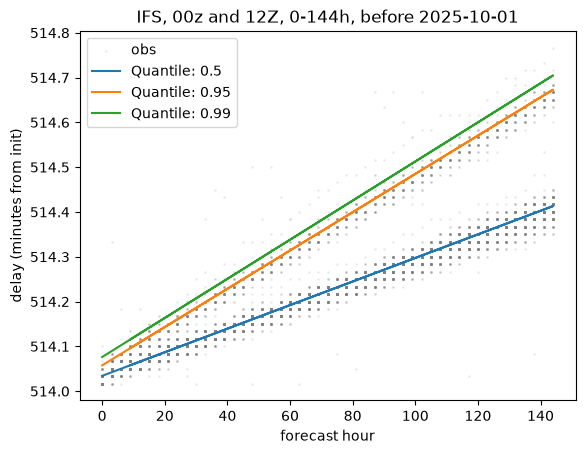

In [96]:
df_filt = df_all[((df_all['init_date'] < '2025-10-01') &
                  (df_all['cycle'].isin(['00', '12'])) &
                  (df_all['forecast_hour'] <= 144))].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('IFS, 00z and 12Z, 0-144h, before 2025-10-01')
plt.show()

And for the 6-hourly steps (> 144 h)

Intercepts (minutes after init)
{0.5: np.float64(514.219333143383), 0.95: np.float64(514.4803596037673), 0.99: np.float64(514.5166652161004)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.0013333366539213635), 0.95: np.float64(0.0015754048052324273), 0.99: np.float64(0.0015432166754141329)}


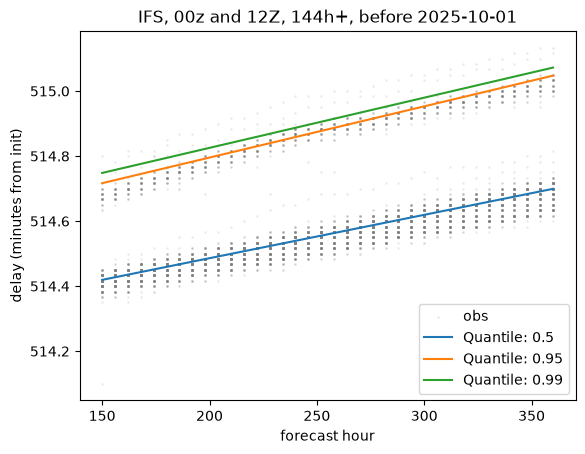

In [97]:
df_filt = df_all[((df_all['init_date'] < '2025-10-01') &
                  (df_all['cycle'].isin(['00', '12'])) &
                  (df_all['forecast_hour'] > 144))].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('IFS, 00z and 12Z, 144h+, before 2025-10-01')
plt.show()

And the 06z and 18z cycles:

Intercepts (minutes after init)
{0.5: np.float64(447.0491885120363), 0.95: np.float64(447.1499999934643), 0.99: np.float64(447.33666583876663)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.003793834532957266), 0.95: np.float64(0.005555551203191866), 0.99: np.float64(0.004222226680750973)}


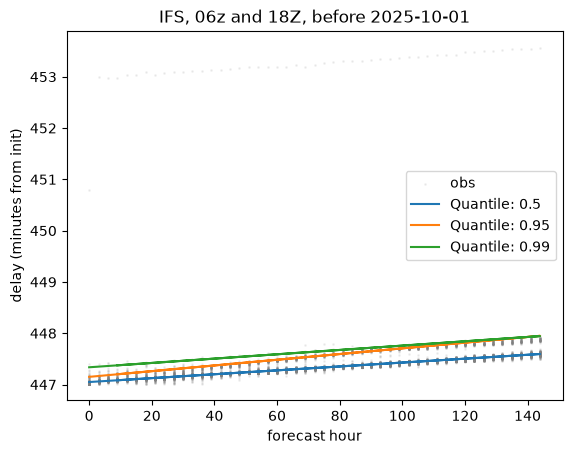

In [98]:
df_filt = df_all[((df_all['init_date'] < '2025-10-01') &
                  (df_all['cycle'].isin(['06', '18'])))].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('IFS, 06z and 18Z, before 2025-10-01')
plt.show()

Now, repeat for the newer schdeule (2025-10-01 and sooner):

Intercepts (minutes after init)
{0.5: np.float64(454.03333312855466), 0.95: np.float64(454.0500023597268), 0.99: np.float64(454.06410258925297)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.0025396097150249502), 0.95: np.float64(0.0027773102860831076), 0.99: np.float64(0.0029914316832760452)}


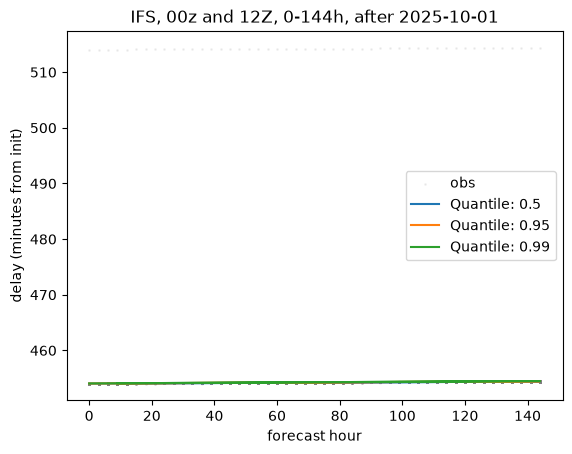

In [99]:
df_filt = df_all[((df_all['init_date'] >= '2025-10-01') &
                  (df_all['cycle'].isin(['00', '12'])) &
                  (df_all['forecast_hour'] <= 144))].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)

plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('IFS, 00z and 12Z, 0-144h, after 2025-10-01')
plt.show()

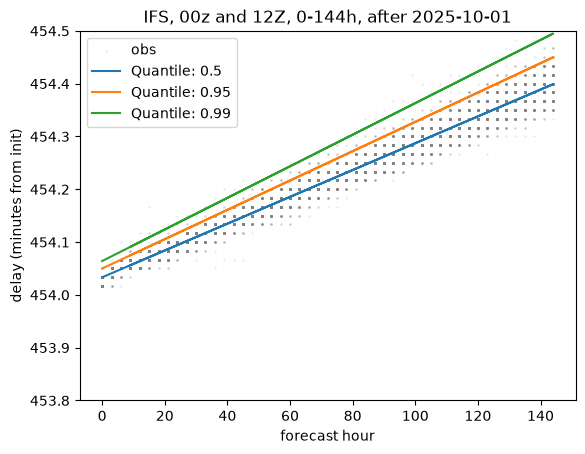

In [100]:
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('IFS, 00z and 12Z, 0-144h, after 2025-10-01')
plt.ylim([453.8,454.5])
plt.show()

Intercepts (minutes after init)
{0.5: np.float64(454.2093902744478), 0.95: np.float64(454.24999900054735), 0.99: np.float64(454.2666660819152)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.0012872105064700614), 0.95: np.float64(0.0013888904739195495), 0.99: np.float64(0.0015873028254578786)}


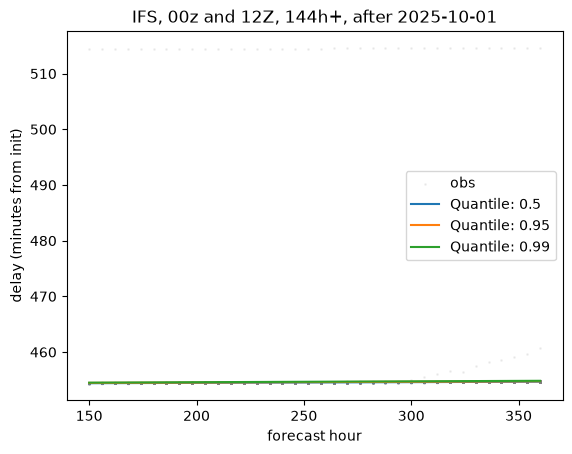

In [101]:
df_filt = df_all[((df_all['init_date'] >= '2025-10-01') &
                  (df_all['cycle'].isin(['00', '12'])) &
                  (df_all['forecast_hour'] > 144))].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)

plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('IFS, 00z and 12Z, 144h+, after 2025-10-01')
plt.show()

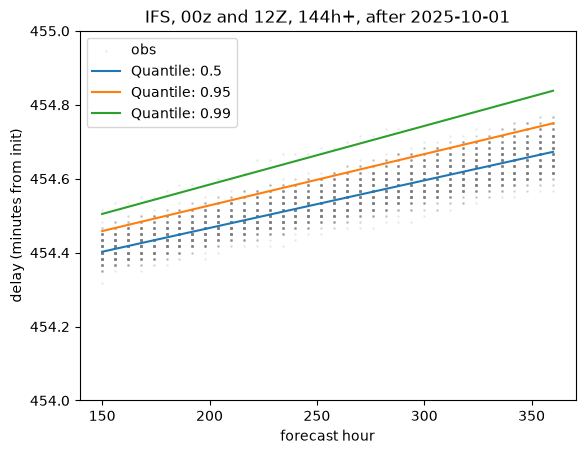

In [102]:
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('IFS, 00z and 12Z, 144h+, after 2025-10-01')
plt.ylim([454,455])
plt.show()

Intercepts (minutes after init)
{0.5: np.float64(387.04791877322435), 0.95: np.float64(387.0645836322995), 0.99: np.float64(387.08809394526577)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.0038193677758020074), 0.95: np.float64(0.00434024444124754), 0.99: np.float64(0.004365085823116955)}


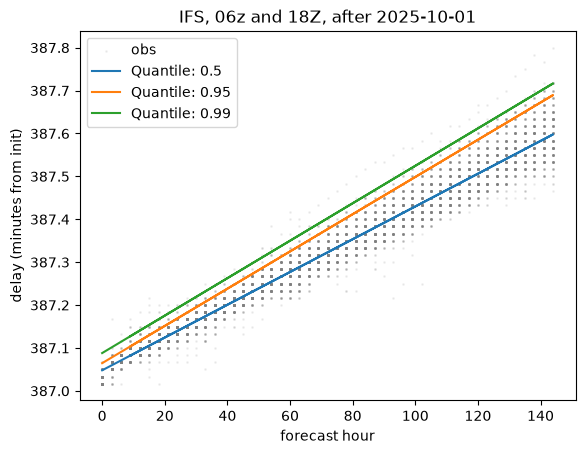

In [103]:
df_filt = df_all[((df_all['init_date'] >= '2025-10-01') &
                  (df_all['cycle'].isin(['06', '18'])))].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)

plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('IFS, 06z and 18Z, after 2025-10-01')
plt.show()

## Recent IFS (naming change, not a schdeule change)

In [111]:
n = 90  # number of random dates
start = '2026-05-13'  # start of random dates
end = '2026-08-11'  # end of random dates 
date_format = '%Y%m%d' #  e.g., 20250101

possible_dates = pd.date_range(start, end, freq='1D')
np.random.seed(42)
idx_random = np.random.permutation(len(possible_dates))[:n]
rand_dates = possible_dates[idx_random].strftime(date_format)
print(rand_dates)

Index(['20260622', '20260604', '20260707', '20260809', '20260513', '20260608',
       '20260621', '20260718', '20260523', '20260626', '20260806', '20260617',
       '20260722', '20260714', '20260525', '20260517', '20260531', '20260610',
       '20260701', '20260716', '20260528', '20260719', '20260729', '20260612',
       '20260615', '20260524', '20260717', '20260720', '20260613', '20260728',
       '20260522', '20260721', '20260518', '20260624', '20260629', '20260529',
       '20260627', '20260616', '20260520', '20260731', '20260609', '20260601',
       '20260727', '20260607', '20260705', '20260526', '20260606', '20260516',
       '20260530', '20260620', '20260521', '20260724', '20260519', '20260808',
       '20260618', '20260802', '20260708', '20260811', '20260706', '20260625',
       '20260702', '20260628', '20260804', '20260713', '20260810', '20260725',
       '20260623', '20260710', '20260630', '20260801', '20260709', '20260614',
       '20260807', '20260711', '20260715', '20260730

In [105]:
cycle = '06'
date = '20260801'

client = boto3.client('s3')
client.meta.events.register('choose-signer.s3.*', disable_signing)

response = client.list_objects_v2(
    Bucket='ecmwf-forecasts',
    Prefix=(f'{date}/{cycle}z/ifs/0p25/oper/'),
    )

max = 10  # max number of files to print 
i = 1
for content in response.get('Contents', []):
    print(content['Key'], content['LastModified'])
    i += 1
    if i > max:
        break

20260801/06z/ifs/0p25/oper/20260801060000-0h-oper-fc.grib2 2026-08-01 12:27:02+00:00
20260801/06z/ifs/0p25/oper/20260801060000-0h-oper-fc.index 2026-08-01 12:27:02+00:00
20260801/06z/ifs/0p25/oper/20260801060000-102h-oper-fc.grib2 2026-08-01 12:27:18+00:00
20260801/06z/ifs/0p25/oper/20260801060000-102h-oper-fc.index 2026-08-01 12:27:18+00:00
20260801/06z/ifs/0p25/oper/20260801060000-105h-oper-fc.grib2 2026-08-01 12:27:19+00:00
20260801/06z/ifs/0p25/oper/20260801060000-105h-oper-fc.index 2026-08-01 12:27:19+00:00
20260801/06z/ifs/0p25/oper/20260801060000-108h-oper-fc.grib2 2026-08-01 12:27:19+00:00
20260801/06z/ifs/0p25/oper/20260801060000-108h-oper-fc.index 2026-08-01 12:27:19+00:00
20260801/06z/ifs/0p25/oper/20260801060000-111h-oper-fc.grib2 2026-08-01 12:27:19+00:00
20260801/06z/ifs/0p25/oper/20260801060000-111h-oper-fc.index 2026-08-01 12:27:20+00:00


In [106]:
dfs = []

for date in rand_dates:
    for cycle in ['00', '06', '12', '18']:
        response = client.list_objects_v2(
            Bucket='ecmwf-forecasts',
            Prefix=(f'{date}/{cycle}z/ifs/0p25/oper/'),
            )
        
        df = pd.DataFrame(response.get('Contents', []))
        filter = (df['Key'].str.contains("fc.grib2"))
        df_filtered = df[filter].copy()

        # split filenames with "-" delimeter, take the second column drop the last character, convert to number
        df_filtered['forecast_hour'] = pd.to_numeric(df_filtered['Key'].str.split('-', expand=True)[1].str[0:-1]).values
        init_date = pd.Timestamp(
            year=int(date[0:4]),
            month=int(date[4:6]),
            day=int(date[6:8]),
            hour=int(cycle),
            minute=0, second=0, tz='UTC')

        delay = (df_filtered['LastModified'] - init_date).dt.total_seconds() / 60
        df_filtered['delay'] = delay
        df_filtered['init_date'] = init_date
        df_filtered['cycle'] = cycle
        dfs.append(df_filtered)

df_all = pd.concat(dfs)

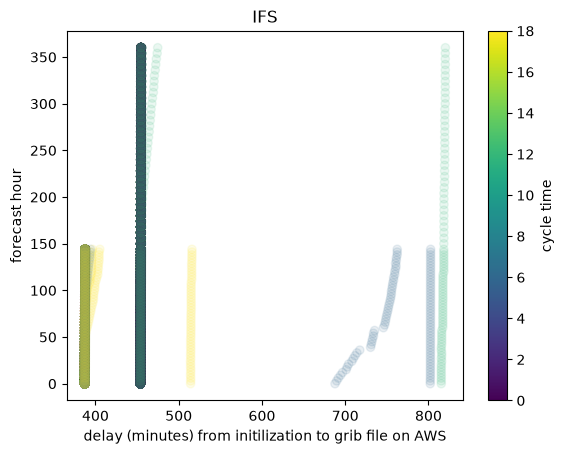

In [107]:
sc = plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=1, c=pd.to_numeric(df_all['cycle']))
cbar = plt.colorbar()
sc.set_alpha(0.1)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file on AWS')
cbar.ax.set_ylabel('cycle time')
plt.title('IFS')
plt.show()

Intercepts (minutes after init)
{0.5: np.float64(454.0333350957802), 0.95: np.float64(454.0473712716833), 0.99: np.float64(454.2940146441414)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.0024999809014343063), 0.95: np.float64(0.004385937520274696), 0.99: np.float64(0.008831924286284579)}


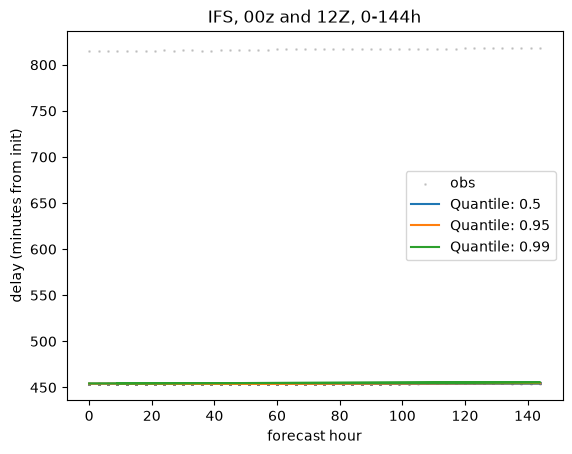

In [108]:
df_filt = df_all[((df_all['cycle'].isin(['00', '12'])) &
                  (df_all['forecast_hour'] <= 144))].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)

plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.3, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('IFS, 00z and 12Z, 0-144h')
plt.show()

Intercepts (minutes after init)
{0.5: np.float64(454.2132168905419), 0.95: np.float64(454.35960640497285), 0.99: np.float64(443.6843746801049)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.0012452151578017487), 0.95: np.float64(0.0022436121368826826), 0.99: np.float64(0.07343749980117543)}


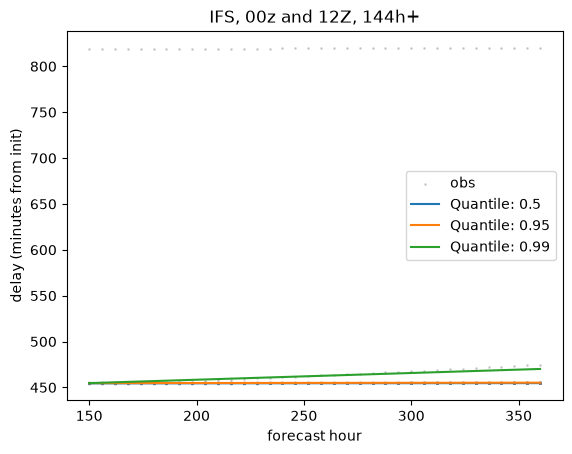

In [109]:
df_filt = df_all[((df_all['cycle'].isin(['00', '12'])) &
                  (df_all['forecast_hour'] > 144))].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)

plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.3, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('IFS, 00z and 12Z, 144h+')
plt.show()

Intercepts (minutes after init)
{0.5: np.float64(387.03427540610124), 0.95: np.float64(387.0427146195923), 0.99: np.float64(690.2516665839792)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.0025397538364974356), 0.95: np.float64(0.006155138396883968), 0.99: np.float64(0.538749999316513)}


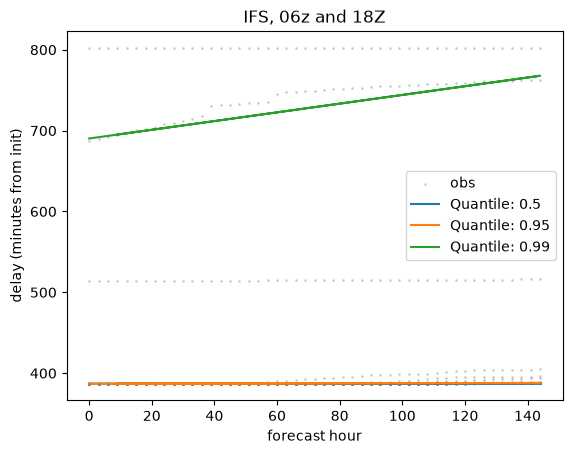

In [110]:
df_filt = df_all[((df_all['cycle'].isin(['06', '18'])))].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)

plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.3, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('IFS, 06z and 18Z')
plt.show()

## IFS Ensemble

In [114]:
n = 200  # number of random dates
start = '2025-01-15'  # start of random dates
end = '2026-05-01'  # end of random dates 
date_format = '%Y%m%d' #  e.g., 20250101

possible_dates = pd.date_range(start, end, freq='1D')
np.random.seed(42)
idx_random = np.random.permutation(len(possible_dates))[:n]
rand_dates = possible_dates[idx_random].strftime(date_format)
print(rand_dates)

Index(['20250311', '20250329', '20250217', '20251020', '20250916', '20260130',
       '20250814', '20250124', '20250521', '20250326',
       ...
       '20260224', '20260222', '20260112', '20260420', '20250220', '20250603',
       '20260114', '20260129', '20251016', '20251010'],
      dtype='str', length=200)


In [115]:
cycle = '00'
date = '20250914'

client = boto3.client('s3')
client.meta.events.register('choose-signer.s3.*', disable_signing)

response = client.list_objects_v2(
    Bucket='ecmwf-forecasts',
    Prefix=(f'{date}/{cycle}z/ifs/0p25/enfo/'),
    )

max = 10  # max number of files to print 
i = 1
for content in response.get('Contents', []):
    print(content['Key'], content['LastModified'])
    i += 1
    if i > max:
        break

20250914/00z/ifs/0p25/enfo/20250914000000-0h-enfo-ef.grib2 2025-09-14 08:40:01+00:00
20250914/00z/ifs/0p25/enfo/20250914000000-0h-enfo-ef.index 2025-09-14 08:40:01+00:00
20250914/00z/ifs/0p25/enfo/20250914000000-102h-enfo-ef.grib2 2025-09-14 08:42:14+00:00
20250914/00z/ifs/0p25/enfo/20250914000000-102h-enfo-ef.index 2025-09-14 08:42:17+00:00
20250914/00z/ifs/0p25/enfo/20250914000000-105h-enfo-ef.grib2 2025-09-14 08:42:33+00:00
20250914/00z/ifs/0p25/enfo/20250914000000-105h-enfo-ef.index 2025-09-14 08:42:34+00:00
20250914/00z/ifs/0p25/enfo/20250914000000-108h-enfo-ef.grib2 2025-09-14 08:42:18+00:00
20250914/00z/ifs/0p25/enfo/20250914000000-108h-enfo-ef.index 2025-09-14 08:42:32+00:00
20250914/00z/ifs/0p25/enfo/20250914000000-111h-enfo-ef.grib2 2025-09-14 08:42:36+00:00
20250914/00z/ifs/0p25/enfo/20250914000000-111h-enfo-ef.index 2025-09-14 08:42:37+00:00


In [116]:
dfs = []

for date in rand_dates:
    for cycle in ['00', '06', '12', '18']:
        if cycle in ['00', '12']:
            response = client.list_objects_v2(
                Bucket='ecmwf-forecasts',
                Prefix=(f'{date}/{cycle}z/ifs/0p25/oper/'),
                )
        else:
            response = client.list_objects_v2(
                Bucket='ecmwf-forecasts',
                Prefix=(f'{date}/{cycle}z/ifs/0p25/scda/'),
                )
        
        df = pd.DataFrame(response.get('Contents', []))
        filter = (df['Key'].str.contains("fc.grib2"))
        df_filtered = df[filter].copy()

        # split filenames with "-" delimeter, take the second column drop the last character, convert to number
        df_filtered['forecast_hour'] = pd.to_numeric(df_filtered['Key'].str.split('-', expand=True)[1].str[0:-1]).values
        init_date = pd.Timestamp(
            year=int(date[0:4]),
            month=int(date[4:6]),
            day=int(date[6:8]),
            hour=int(cycle),
            minute=0, second=0, tz='UTC')

        delay = (df_filtered['LastModified'] - init_date).dt.total_seconds() / 60
        df_filtered['delay'] = delay
        df_filtered['init_date'] = init_date
        df_filtered['cycle'] = cycle
        dfs.append(df_filtered)

df_all = pd.concat(dfs)

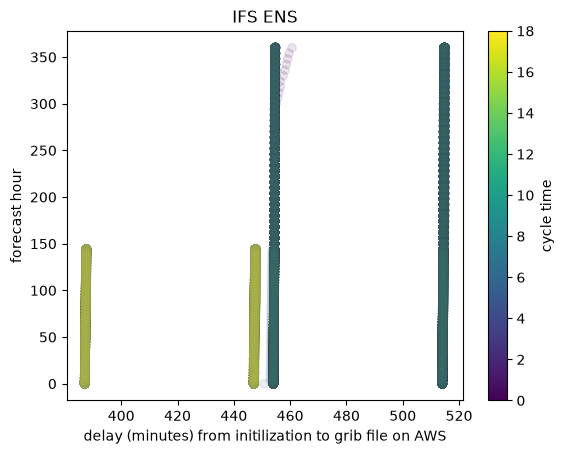

In [117]:
sc = plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=1, c=pd.to_numeric(df_all['cycle']))
cbar = plt.colorbar()
sc.set_alpha(0.1)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file on AWS')
cbar.ax.set_ylabel('cycle time')
plt.title('IFS ENS')
plt.show()

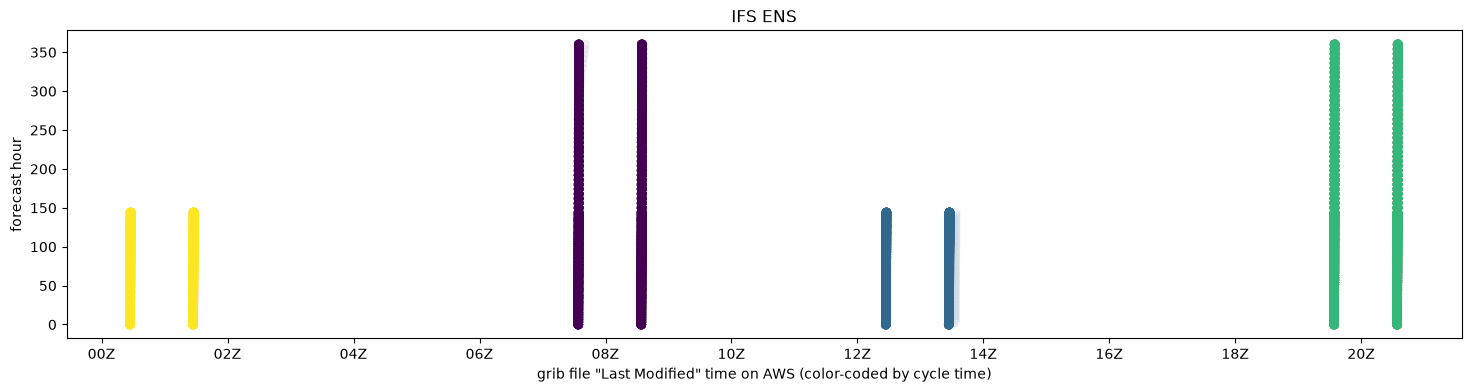

In [118]:
plt.figure(figsize=(18,4))
plt.scatter(pd.to_datetime(df_all['LastModified'].dt.time, format='%H:%M:%S'), df_all['forecast_hour'], alpha=0.05, c=pd.to_numeric(df_all['cycle']))
# plt.colorbar()
plt.ylabel('forecast hour')
plt.xlabel('grib file "Last Modified" time on AWS (color-coded by cycle time)')
plt.title('IFS ENS')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%HZ'))
plt.show()

Intercepts (minutes after init)
{0.5: np.float64(514.0350014434265), 0.95: np.float64(514.0576921276568), 0.99: np.float64(514.0794675240613)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.0026387207798926563), 0.95: np.float64(0.004273514524688264), 0.99: np.float64(0.004351671405581408)}


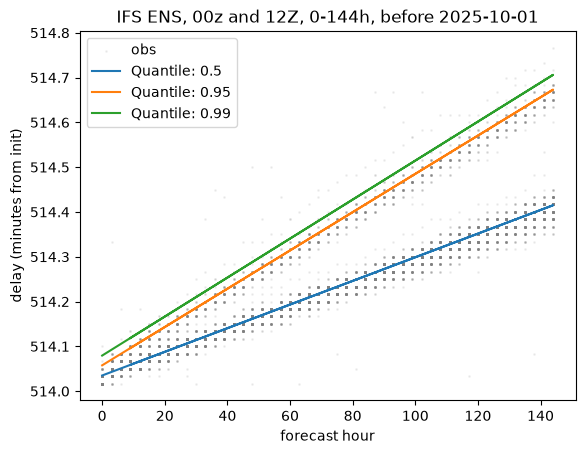

In [119]:
df_filt = df_all[((df_all['init_date'] < '2025-10-01') &
                  (df_all['cycle'].isin(['00', '12'])) &
                  (df_all['forecast_hour'] <= 144))].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('IFS ENS, 00z and 12Z, 0-144h, before 2025-10-01')
plt.show()

Intercepts (minutes after init)
{0.5: np.float64(514.2083797967954), 0.95: np.float64(514.4785717880129), 0.99: np.float64(514.5095384835)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.0013886909531594252), 0.95: np.float64(0.0015872982085276116), 0.99: np.float64(0.0015872093648833783)}


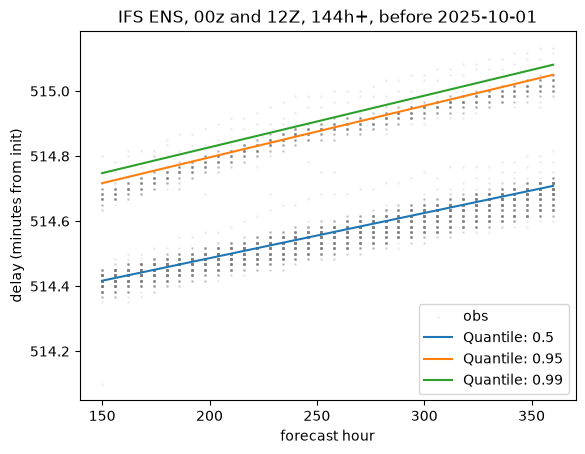

In [120]:
df_filt = df_all[((df_all['init_date'] < '2025-10-01') &
                  (df_all['cycle'].isin(['00', '12'])) &
                  (df_all['forecast_hour'] > 144))].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('IFS ENS, 00z and 12Z, 144h+, before 2025-10-01')
plt.show()

Intercepts (minutes after init)
{0.5: np.float64(447.04904899304665), 0.95: np.float64(447.1500000094017), 0.99: np.float64(447.3458243142752)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.0038095107058254336), 0.95: np.float64(0.00555555411616882), 0.99: np.float64(0.004166732225589393)}


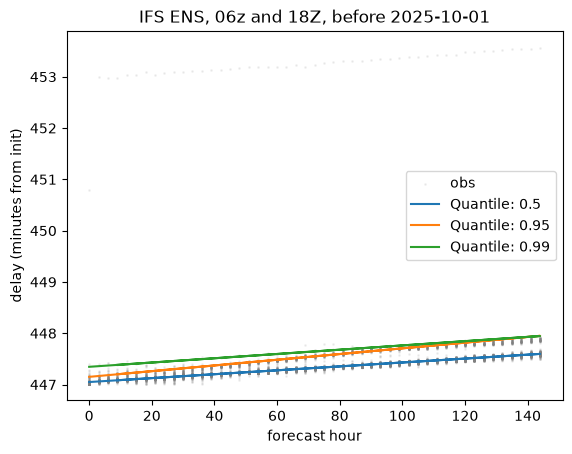

In [121]:
df_filt = df_all[((df_all['init_date'] < '2025-10-01') &
                  (df_all['cycle'].isin(['06', '18'])))].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('IFS ENS, 06z and 18Z, before 2025-10-01')
plt.show()

Intercepts (minutes after init)
{0.5: np.float64(454.03333372021007), 0.95: np.float64(454.0500048963451), 0.99: np.float64(454.06665751485616)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.0025515146904138454), 0.95: np.float64(0.0027768841937329545), 0.99: np.float64(0.0027778594772665637)}


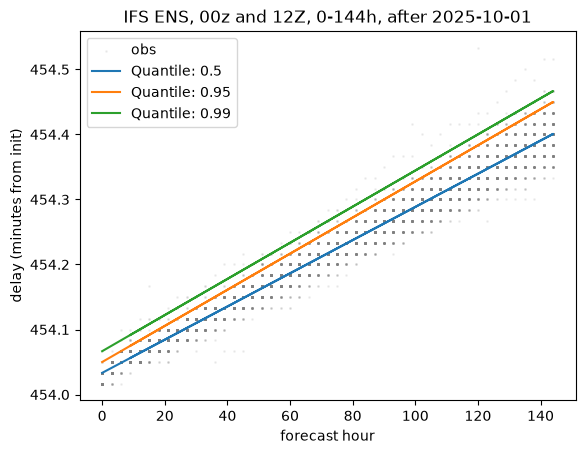

In [122]:
df_filt = df_all[((df_all['init_date'] >= '2025-10-01') &
                  (df_all['cycle'].isin(['00', '12'])) &
                  (df_all['forecast_hour'] <= 144))].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('IFS ENS, 00z and 12Z, 0-144h, after 2025-10-01')
plt.show()

Intercepts (minutes after init)
{0.5: np.float64(454.21282135790227), 0.95: np.float64(454.2499976951214), 0.99: np.float64(454.2666661685524)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.0012820485801214418), 0.95: np.float64(0.0013888941479618863), 0.99: np.float64(0.0013888903591784798)}


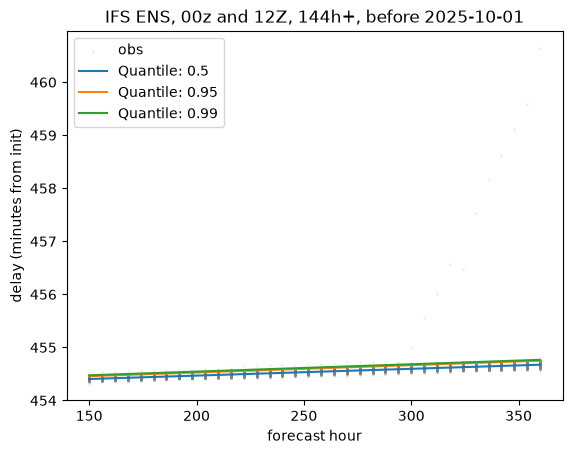

In [125]:
df_filt = df_all[((df_all['init_date'] >= '2025-10-01') &
                  (df_all['cycle'].isin(['00', '12'])) &
                  (df_all['forecast_hour'] > 144))].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('IFS ENS, 00z and 12Z, 144h+, before 2025-10-01')
plt.show()

Intercepts (minutes after init)
{0.5: np.float64(387.0475327432825), 0.95: np.float64(387.0644160384557), 0.99: np.float64(387.0868747774367)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.003844519534521316), 0.95: np.float64(0.00435420661620307), 0.99: np.float64(0.004375034735103112)}


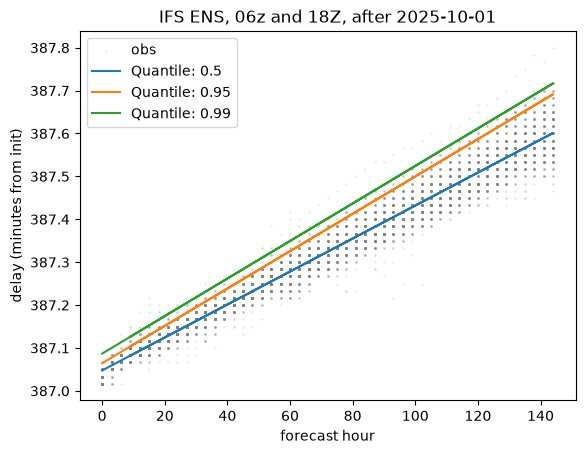

In [124]:
df_filt = df_all[((df_all['init_date'] >= '2025-10-01') &
                  (df_all['cycle'].isin(['06', '18'])))].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('IFS ENS, 06z and 18Z, after 2025-10-01')
plt.show()

## AIFS

In [151]:
n = 200  # number of random dates
start = '2025-02-26'  # start of random dates, 'aifs-single' names started 20250206
end = '2026-08-01'  # end of random dates 
date_format = '%Y%m%d' #  e.g., 20250101

possible_dates = pd.date_range(start, end, freq='1D')
np.random.seed(42)
idx_random = np.random.permutation(len(possible_dates))[:n]
rand_dates = possible_dates[idx_random].strftime(date_format)
print(rand_dates)

Index(['20260506', '20260512', '20250304', '20250829', '20250515', '20251222',
       '20260801', '20260625', '20250623', '20250713',
       ...
       '20250404', '20250802', '20260701', '20250624', '20250620', '20251124',
       '20250820', '20250922', '20250917', '20250720'],
      dtype='str', length=200)


In [153]:
cycle = '00'
date = '20250226'

client = boto3.client('s3')
client.meta.events.register('choose-signer.s3.*', disable_signing)

response = client.list_objects_v2(
    Bucket='ecmwf-forecasts',
    Prefix=(f'{date}/{cycle}z/aifs-single/0p25/oper/'),
    )

max = 10  # max number of files to print 
i = 1
for content in response.get('Contents', []):
    print(content['Key'], content['LastModified'])
    i += 1
    if i > max:
        break

20250226/00z/aifs-single/0p25/oper/20250226000000-0h-oper-fc.grib2 2025-02-26 05:15:06+00:00
20250226/00z/aifs-single/0p25/oper/20250226000000-0h-oper-fc.index 2025-02-26 05:15:06+00:00
20250226/00z/aifs-single/0p25/oper/20250226000000-102h-oper-fc.grib2 2025-02-26 05:15:01+00:00
20250226/00z/aifs-single/0p25/oper/20250226000000-102h-oper-fc.index 2025-02-26 05:15:01+00:00
20250226/00z/aifs-single/0p25/oper/20250226000000-108h-oper-fc.grib2 2025-02-26 05:14:59+00:00
20250226/00z/aifs-single/0p25/oper/20250226000000-108h-oper-fc.index 2025-02-26 05:15:00+00:00
20250226/00z/aifs-single/0p25/oper/20250226000000-114h-oper-fc.grib2 2025-02-26 05:15:03+00:00
20250226/00z/aifs-single/0p25/oper/20250226000000-114h-oper-fc.index 2025-02-26 05:15:03+00:00
20250226/00z/aifs-single/0p25/oper/20250226000000-120h-oper-fc.grib2 2025-02-26 05:15:07+00:00
20250226/00z/aifs-single/0p25/oper/20250226000000-120h-oper-fc.index 2025-02-26 05:15:07+00:00


In [154]:
df = pd.DataFrame(response.get('Contents', []))
df

,Key,LastModified,ETag,ChecksumAlgorithm,ChecksumType,Size,StorageClass
0,20250226/00z/aifs-single/0p25/oper/20250226000...,2025-02-26 05:15:06+00:00,"""5df2a00769ceadf413770f3a2fa89b49""",[CRC64NVME],FULL_OBJECT,80366631,INTELLIGENT_TIERING
1,20250226/00z/aifs-single/0p25/oper/20250226000...,2025-02-26 05:15:06+00:00,"""11f48b981f9900b82c1fcb9ee0394482""",[CRC64NVME],FULL_OBJECT,22926,STANDARD
2,20250226/00z/aifs-single/0p25/oper/20250226000...,2025-02-26 05:15:01+00:00,"""18487d62752676d79fd13aa51c4ca946""",[CRC64NVME],FULL_OBJECT,75091628,INTELLIGENT_TIERING
3,20250226/00z/aifs-single/0p25/oper/20250226000...,2025-02-26 05:15:01+00:00,"""e8c11f83e1d55c78ed4cda361f565604""",[CRC64NVME],FULL_OBJECT,22330,STANDARD
4,20250226/00z/aifs-single/0p25/oper/20250226000...,2025-02-26 05:14:59+00:00,"""dcfeecea3549672036de418ab62a7b74""",[CRC64NVME],FULL_OBJECT,76032593,INTELLIGENT_TIERING
...,...,...,...,...,...,...,...
120,20250226/00z/aifs-single/0p25/oper/20250226000...,2025-02-26 05:14:56+00:00,"""a9df9a0c4023a89074e9ce21c976ced0""",[CRC64NVME],FULL_OBJECT,22233,STANDARD
121,20250226/00z/aifs-single/0p25/oper/20250226000...,2025-02-26 05:15:03+00:00,"""670c1ba27e87efca82b88ad72e0dd4cb""",[CRC64NVME],FULL_OBJECT,75079379,INTELLIGENT_TIERING
122,20250226/00z/aifs-single/0p25/oper/20250226000...,2025-02-26 05:15:03+00:00,"""92978d82a2bfbf98565618fee5ebd769""",[CRC64NVME],FULL_OBJECT,22229,STANDARD
123,20250226/00z/aifs-single/0p25/oper/LICENCE.txt,2025-02-26 05:15:06+00:00,"""0078c4dd3fa92595b81fb4900df7a56d""",[CRC64NVME],FULL_OBJECT,108,STANDARD


In [155]:
filter = (df['Key'].str.contains("fc.grib2"))
df_filtered = df[filter].copy()
print(len(df_filtered))
df_filtered.head()

61


,Key,LastModified,ETag,ChecksumAlgorithm,ChecksumType,Size,StorageClass
0,20250226/00z/aifs-single/0p25/oper/20250226000...,2025-02-26 05:15:06+00:00,"""5df2a00769ceadf413770f3a2fa89b49""",[CRC64NVME],FULL_OBJECT,80366631,INTELLIGENT_TIERING
2,20250226/00z/aifs-single/0p25/oper/20250226000...,2025-02-26 05:15:01+00:00,"""18487d62752676d79fd13aa51c4ca946""",[CRC64NVME],FULL_OBJECT,75091628,INTELLIGENT_TIERING
4,20250226/00z/aifs-single/0p25/oper/20250226000...,2025-02-26 05:14:59+00:00,"""dcfeecea3549672036de418ab62a7b74""",[CRC64NVME],FULL_OBJECT,76032593,INTELLIGENT_TIERING
6,20250226/00z/aifs-single/0p25/oper/20250226000...,2025-02-26 05:15:03+00:00,"""620ac2e74b00df45ff166620115e27e5""",[CRC64NVME],FULL_OBJECT,75853608,INTELLIGENT_TIERING
8,20250226/00z/aifs-single/0p25/oper/20250226000...,2025-02-26 05:15:07+00:00,"""07b52a93faa6657f9aca23708b344889""",[CRC64NVME],FULL_OBJECT,75673706,INTELLIGENT_TIERING


In [156]:
# get second column because the model name `aifs-single` has a hyphen in it
df_filtered['Key'].str.split('-', expand=True)[2].str[0:-1]

0        0
2      102
4      108
6      114
8      120
      ... 
113     72
115     78
117     84
119     90
121     96
Name: 2, Length: 61, dtype: str

In [157]:
rand_dates = rand_dates.append(pd.date_range('2025-09-25', '2025-10-05', freq='1D').strftime(date_format))

In [158]:
dfs = []

for date in rand_dates:
    for cycle in ['00', '06', '12', '18']:
        response = client.list_objects_v2(
            Bucket='ecmwf-forecasts',
            Prefix=(f'{date}/{cycle}z/aifs-single/0p25/oper/'),
            )
        
        df = pd.DataFrame(response.get('Contents', []))
        filter = (df['Key'].str.contains("fc.grib2"))
        df_filtered = df[filter].copy()

        # split filenames with "-" delimeter, take the second column drop the last character, convert to number
        df_filtered['forecast_hour'] = pd.to_numeric(df_filtered['Key'].str.split('-', expand=True)[2].str[0:-1]).values
        init_date = pd.Timestamp(
            year=int(date[0:4]),
            month=int(date[4:6]),
            day=int(date[6:8]),
            hour=int(cycle),
            minute=0, second=0, tz='UTC')

        delay = (df_filtered['LastModified'] - init_date).dt.total_seconds() / 60
        df_filtered['delay'] = delay
        df_filtered['init_date'] = init_date
        df_filtered['cycle'] = cycle
        dfs.append(df_filtered)

df_all = pd.concat(dfs)

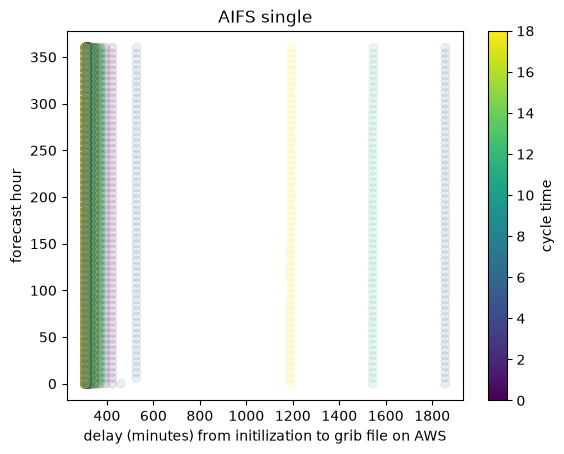

In [159]:
sc = plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=1, c=pd.to_numeric(df_all['cycle']))
cbar = plt.colorbar()
sc.set_alpha(0.1)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file on AWS')
cbar.ax.set_ylabel('cycle time')
plt.title('AIFS single')
plt.show()

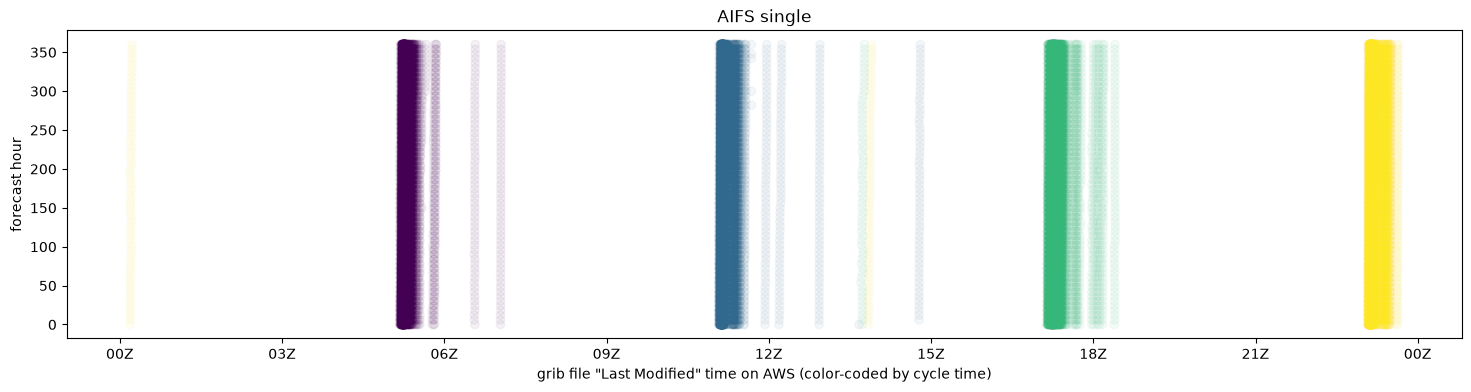

In [160]:
plt.figure(figsize=(18,4))
plt.scatter(pd.to_datetime(df_all['LastModified'].dt.time, format='%H:%M:%S'), df_all['forecast_hour'], alpha=0.05, c=pd.to_numeric(df_all['cycle']))
# plt.colorbar()
plt.ylabel('forecast hour')
plt.xlabel('grib file "Last Modified" time on AWS (color-coded by cycle time)')
plt.title('AIFS single')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%HZ'))
plt.show()

Intercepts (minutes after init)
{0.5: np.float64(310.5060618093256), 0.95: np.float64(320.2929630072519), 0.99: np.float64(393.1008555331918)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.006691846586748359), 0.95: np.float64(0.003271603257863509), 0.99: np.float64(0.0015669197066924471)}


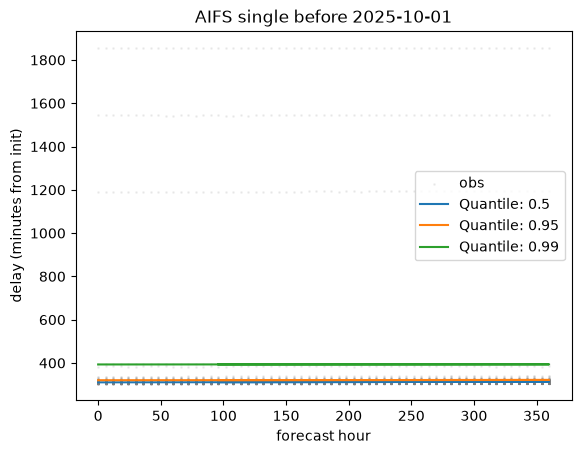

In [164]:
df_filt = df_all[(df_all['init_date'] < '2025-10-01')].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('AIFS single before 2025-10-01')
plt.show()

Intercepts (minutes after init)
{0.5: np.float64(314.9766660272439), 0.95: np.float64(331.5507185891226), 0.99: np.float64(369.98222246990827)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.0031666695917577314), 0.95: np.float64(0.0063405945219568065), 0.99: np.float64(0.00564533730113878)}


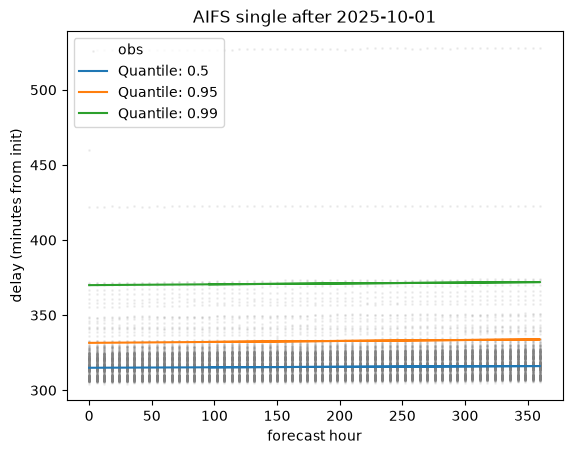

In [165]:
df_filt = df_all[(df_all['init_date'] >= '2025-10-01')].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('AIFS single after 2025-10-01')
plt.show()

Intercepts (minutes after init)
{0.5: np.float64(313.26875007167763), 0.95: np.float64(328.0916692013621), 0.99: np.float64(371.3327582242008)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.0032598878555243787), 0.95: np.float64(0.005176720630095369), 0.99: np.float64(0.005363984570877694)}


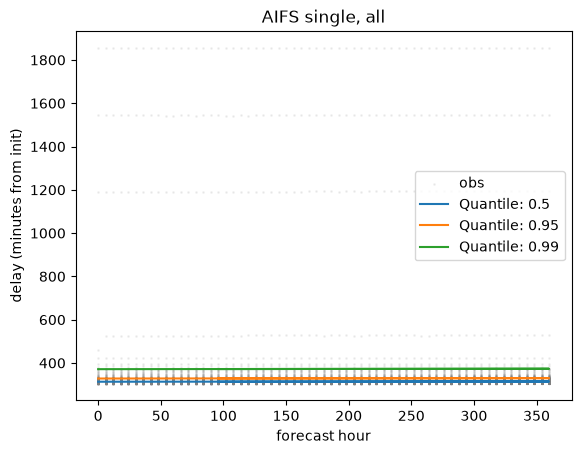

In [166]:
df = df_all

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('AIFS single, all')
plt.show()

## AIFS Ensemble

Started 2025-07-03

In [167]:
n = 200  # number of random dates
start = '2025-07-03'  # start of random dates, 'aifs-single' names started 20250206
end = '2026-08-01'  # end of random dates 
date_format = '%Y%m%d' #  e.g., 20250101

possible_dates = pd.date_range(start, end, freq='1D')
np.random.seed(42)
idx_random = np.random.permutation(len(possible_dates))[:n]
rand_dates = possible_dates[idx_random].strftime(date_format)
print(rand_dates)

Index(['20250919', '20260709', '20260308', '20250827', '20260728', '20260211',
       '20250814', '20260222', '20260515', '20251027',
       ...
       '20260601', '20260114', '20260403', '20260427', '20260102', '20260208',
       '20260511', '20260604', '20260407', '20251109'],
      dtype='str', length=200)


In [172]:
cycle = '00'
date = '20260703'

client = boto3.client('s3')
client.meta.events.register('choose-signer.s3.*', disable_signing)

response = client.list_objects_v2(
    Bucket='ecmwf-forecasts',
    Prefix=(f'{date}/{cycle}z/aifs-ens/0p25/enfo/'),
    )

max = 10  # max number of files to print 
i = 1
for content in response.get('Contents', []):
    print(content['Key'], content['LastModified'])
    i += 1
    if i > max:
        break

20260703/00z/aifs-ens/0p25/enfo/20260703000000-0h-enfo-cf.grib2 2026-07-03 06:01:53+00:00
20260703/00z/aifs-ens/0p25/enfo/20260703000000-0h-enfo-cf.index 2026-07-03 06:01:53+00:00
20260703/00z/aifs-ens/0p25/enfo/20260703000000-0h-enfo-pf.grib2 2026-07-03 06:01:54+00:00
20260703/00z/aifs-ens/0p25/enfo/20260703000000-0h-enfo-pf.index 2026-07-03 06:01:55+00:00
20260703/00z/aifs-ens/0p25/enfo/20260703000000-102h-enfo-cf.grib2 2026-07-03 06:23:59+00:00
20260703/00z/aifs-ens/0p25/enfo/20260703000000-102h-enfo-cf.index 2026-07-03 06:24:01+00:00
20260703/00z/aifs-ens/0p25/enfo/20260703000000-102h-enfo-pf.grib2 2026-07-03 06:24:02+00:00
20260703/00z/aifs-ens/0p25/enfo/20260703000000-102h-enfo-pf.index 2026-07-03 06:24:04+00:00
20260703/00z/aifs-ens/0p25/enfo/20260703000000-108h-enfo-cf.grib2 2026-07-03 06:23:43+00:00
20260703/00z/aifs-ens/0p25/enfo/20260703000000-108h-enfo-cf.index 2026-07-03 06:23:45+00:00


In [173]:
df = pd.DataFrame(response.get('Contents', []))
df

,Key,LastModified,ETag,ChecksumAlgorithm,ChecksumType,Size,StorageClass
0,20260703/00z/aifs-ens/0p25/enfo/20260703000000...,2026-07-03 06:01:53+00:00,"""7fd01dd087f0137d114084f8721dd39b""",[CRC32],FULL_OBJECT,84654272,INTELLIGENT_TIERING
1,20260703/00z/aifs-ens/0p25/enfo/20260703000000...,2026-07-03 06:01:53+00:00,"""187718f2908f9c5df6a8593e13b12569""",[CRC32],FULL_OBJECT,26577,STANDARD
2,20260703/00z/aifs-ens/0p25/enfo/20260703000000...,2026-07-03 06:01:54+00:00,"""0f7a2945dd8aafbcbb02b93304d191e9""",[CRC32],FULL_OBJECT,4339386856,INTELLIGENT_TIERING
3,20260703/00z/aifs-ens/0p25/enfo/20260703000000...,2026-07-03 06:01:55+00:00,"""bc9e3b813f5e865477c84fb12b894cfd""",[CRC32],FULL_OBJECT,1428226,INTELLIGENT_TIERING
4,20260703/00z/aifs-ens/0p25/enfo/20260703000000...,2026-07-03 06:23:59+00:00,"""7a38310b2d5ce231b2d8f9d5ae7e7683""",[CRC32],FULL_OBJECT,89098790,INTELLIGENT_TIERING
...,...,...,...,...,...,...,...
246,20260703/00z/aifs-ens/0p25/enfo/20260703000000...,2026-07-03 06:18:17+00:00,"""b29176a0724ad3174de973507018e428""",[CRC32],FULL_OBJECT,25804,STANDARD
247,20260703/00z/aifs-ens/0p25/enfo/20260703000000...,2026-07-03 06:17:45+00:00,"""e81aa268326e828bf42b057115eb7815""",[CRC32],FULL_OBJECT,4450916551,INTELLIGENT_TIERING
248,20260703/00z/aifs-ens/0p25/enfo/20260703000000...,2026-07-03 06:18:15+00:00,"""f07e880bf681b5402336ce78d4754911""",[CRC32],FULL_OBJECT,1386167,INTELLIGENT_TIERING
249,20260703/00z/aifs-ens/0p25/enfo/LICENCE.txt,2026-07-03 06:01:53+00:00,"""0078c4dd3fa92595b81fb4900df7a56d""",[CRC32],FULL_OBJECT,108,STANDARD


In [176]:
filter = (df['Key'].str.contains("cf.grib2"))
df_filtered = df[filter].copy()
print(len(df_filtered))
df_filtered.head()

61


,Key,LastModified,ETag,ChecksumAlgorithm,ChecksumType,Size,StorageClass
0,20260703/00z/aifs-ens/0p25/enfo/20260703000000...,2026-07-03 06:01:53+00:00,"""7fd01dd087f0137d114084f8721dd39b""",[CRC32],FULL_OBJECT,84654272,INTELLIGENT_TIERING
4,20260703/00z/aifs-ens/0p25/enfo/20260703000000...,2026-07-03 06:23:59+00:00,"""7a38310b2d5ce231b2d8f9d5ae7e7683""",[CRC32],FULL_OBJECT,89098790,INTELLIGENT_TIERING
8,20260703/00z/aifs-ens/0p25/enfo/20260703000000...,2026-07-03 06:23:43+00:00,"""c0af1a6f13032c9990b8b5dd21da70c3""",[CRC32],FULL_OBJECT,89268612,INTELLIGENT_TIERING
12,20260703/00z/aifs-ens/0p25/enfo/20260703000000...,2026-07-03 06:14:17+00:00,"""34c7757ae58c6db08c2c4d422d5aeb1b""",[CRC32],FULL_OBJECT,88955499,INTELLIGENT_TIERING
16,20260703/00z/aifs-ens/0p25/enfo/20260703000000...,2026-07-03 06:19:07+00:00,"""d00a6e01e8ef932cdc013025e441fb78""",[CRC32],FULL_OBJECT,89166963,INTELLIGENT_TIERING


In [ ]:
# get second column because the model name `aifs-ens` has a hyphen in it
df_filtered['Key'].str.split('-', expand=True)[2].str[0:-1]

0        0
4      102
8      108
12     114
16     120
      ... 
229     72
233     78
237     84
241     90
245     96
Name: 2, Length: 61, dtype: str

In [180]:
dfs = []

for date in rand_dates:
    for cycle in ['00', '06', '12', '18']:
        response = client.list_objects_v2(
            Bucket='ecmwf-forecasts',
            Prefix=(f'{date}/{cycle}z/aifs-ens/0p25/enfo/'),
            )
        
        df = pd.DataFrame(response.get('Contents', []))
        filter = (df['Key'].str.contains("cf.grib2"))
        df_filtered = df[filter].copy()

        # split filenames with "-" delimeter, take the second column drop the last character, convert to number
        df_filtered['forecast_hour'] = pd.to_numeric(df_filtered['Key'].str.split('-', expand=True)[2].str[0:-1]).values
        init_date = pd.Timestamp(
            year=int(date[0:4]),
            month=int(date[4:6]),
            day=int(date[6:8]),
            hour=int(cycle),
            minute=0, second=0, tz='UTC')

        delay = (df_filtered['LastModified'] - init_date).dt.total_seconds() / 60
        df_filtered['delay'] = delay
        df_filtered['init_date'] = init_date
        df_filtered['cycle'] = cycle
        dfs.append(df_filtered)

df_all = pd.concat(dfs)

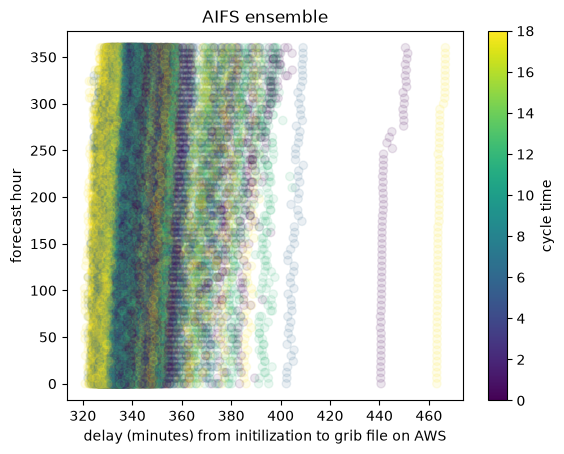

In [181]:
sc = plt.scatter(df_all['delay'], df_all['forecast_hour'], alpha=1, c=pd.to_numeric(df_all['cycle']))
cbar = plt.colorbar()
sc.set_alpha(0.1)
plt.ylabel('forecast hour')
plt.xlabel('delay (minutes) from initilization to grib file on AWS')
cbar.ax.set_ylabel('cycle time')
plt.title('AIFS ensemble')
plt.show()

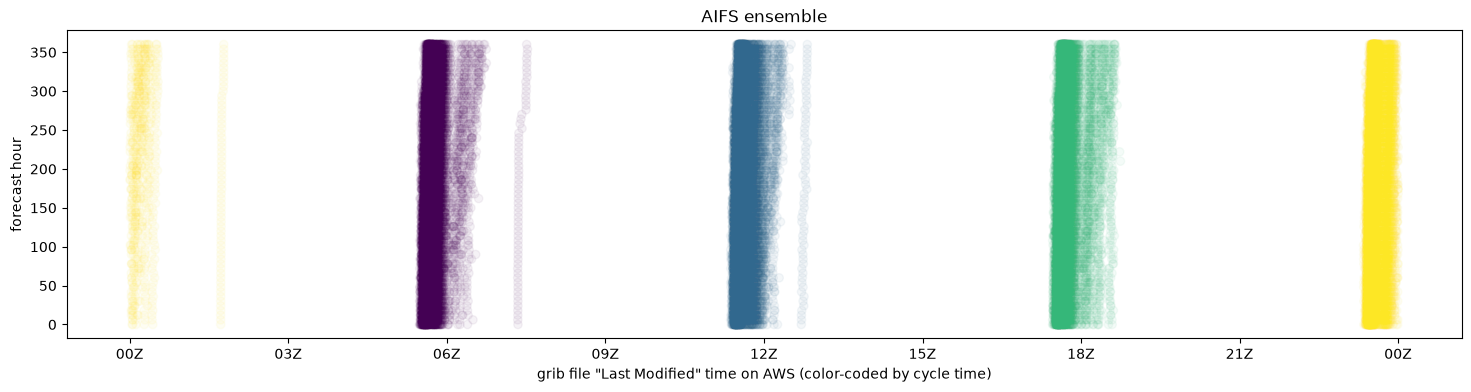

In [182]:
plt.figure(figsize=(18,4))
plt.scatter(pd.to_datetime(df_all['LastModified'].dt.time, format='%H:%M:%S'), df_all['forecast_hour'], alpha=0.05, c=pd.to_numeric(df_all['cycle']))
# plt.colorbar()
plt.ylabel('forecast hour')
plt.xlabel('grib file "Last Modified" time on AWS (color-coded by cycle time)')
plt.title('AIFS ensemble')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%HZ'))
plt.show()

Intercepts (minutes after init)
{0.5: np.float64(332.81408490244536), 0.95: np.float64(344.24202913682984), 0.99: np.float64(391.4097236353165)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.015171250439401528), 0.95: np.float64(0.014975844348098604), 0.99: np.float64(0.003934944210847759)}


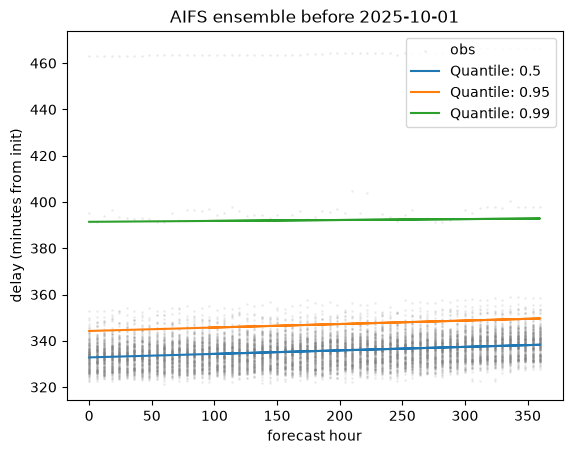

In [183]:
df_filt = df_all[(df_all['init_date'] < '2025-10-01')].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('AIFS ensemble before 2025-10-01')
plt.show()

Intercepts (minutes after init)
{0.5: np.float64(335.8833342438151), 0.95: np.float64(357.94999975452805), 0.99: np.float64(377.8317202235149)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.015169291379739968), 0.95: np.float64(0.06383511474204935), 0.99: np.float64(0.05331540920254122)}


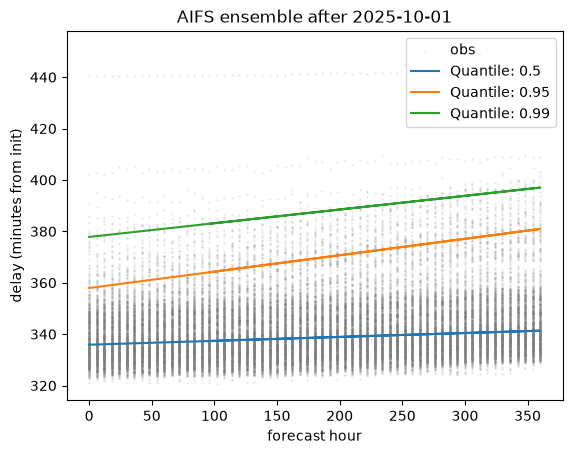

In [184]:
df_filt = df_all[(df_all['init_date'] >= '2025-10-01')].copy()
df = df_filt

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('AIFS ensemble after 2025-10-01')
plt.show()

Intercepts (minutes after init)
{0.5: np.float64(334.7779987029045), 0.95: np.float64(355.18333234337223), 0.99: np.float64(377.92309530672674)}
Slopes (minutes per forecast hour):
{0.5: np.float64(0.015444449666773646), 0.95: np.float64(0.06255556013560304), 0.99: np.float64(0.052991069129259966)}


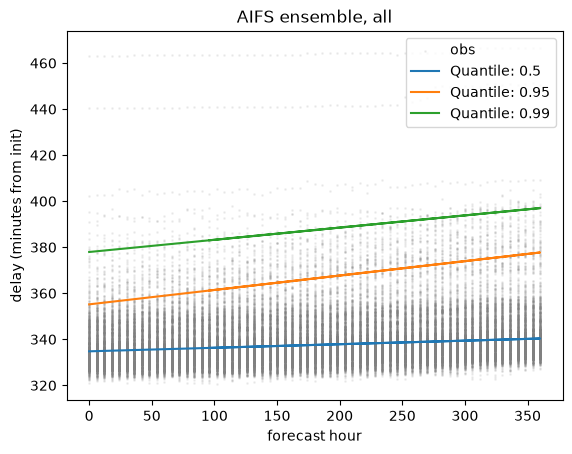

In [185]:
df = df_all

slopes = {}
intercepts = {}
mod = smf.quantreg("delay ~ forecast_hour", df)
for quantile in quantiles:
    res = mod.fit(q=quantile)
    slopes[quantile] = res.params['forecast_hour']
    intercepts[quantile] = res.params['Intercept']

print('Intercepts (minutes after init)')
print(intercepts)
print('Slopes (minutes per forecast hour):')
print(slopes)
plt.scatter(df['forecast_hour'], df['delay'],
            s=1, alpha=0.1, color='gray', label='obs')

for q in quantiles:
    plt.plot(df['forecast_hour'],
             df['forecast_hour']*slopes[q] + intercepts[q],
             label=f"Quantile: {q}")

plt.xlabel('forecast hour')
plt.ylabel('delay (minutes from init)')
plt.legend()
plt.title('AIFS ensemble, all')
plt.show()